# Práctica Guiada: Construcción y Experimentación con MLPs

Integrantes:
- Maria José Murillo Mendoza
- Laura Camacho Lipa
- Andrés Revollo Almendras

# Configuración General del Entorno

En esta sección se importan las bibliotecas necesarias y se definen los parámetros iniciales del experimento.

El objetivo es establecer un entorno de trabajo reproducible para el entrenamiento de redes neuronales multicapa (MLPs) utilizando **PyTorch**, siguiendo los requerimientos de la práctica.

Se utilizarán herramientas para:

- **Manipulación de datos:** `pandas`, `numpy`
- **Construcción de redes neuronales:** `torch`, `torch.nn`
- **Carga eficiente de datos:** `DataLoader`, `TensorDataset`
- **Monitoreo del entrenamiento:** `TensorBoard`
- **Preprocesamiento y partición de datos:** `scikit-learn`

Además, se configurará automáticamente el dispositivo de ejecución (**CPU o GPU**) dependiendo de la disponibilidad del entorno, permitiendo acelerar el entrenamiento cuando exista soporte CUDA.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

In [2]:
BATCH_SIZE = 32
DATA_PATH = 'fifa2021_training.csv'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Usando dispositivo:", DEVICE)

Usando dispositivo: cpu


In [3]:
def load_array(data_arrays, batch_size, is_train=True):
    """Crea un DataLoader desde tensores."""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train)

## Función `evaluate_loss()`

### Objetivo

Evaluar el desempeño del modelo sobre un conjunto de datos mediante el cálculo de la **pérdida promedio (loss)**.

Esta métrica permite cuantificar qué tan alejadas están las predicciones realizadas por la red neuronal respecto a las etiquetas reales del dataset.

### ¿Qué realiza esta función?

Durante la evaluación, el modelo procesa todos los datos de entrada sin actualizar sus pesos, obteniendo una estimación objetiva del error actual de la red.

El procedimiento seguido es:

1. Se cambia el modelo a **modo evaluación** mediante `eval()`, desactivando comportamientos específicos de entrenamiento (por ejemplo, `Dropout` o `BatchNorm`).

2. Se utiliza `torch.no_grad()` para desactivar el cálculo de gradientes, reduciendo el consumo de memoria y acelerando la ejecución.

3. Para cada batch del conjunto de datos:
   - Se generan predicciones.
   - Se calcula la pérdida usando la función de costo definida.
   - Se acumula el error ponderado por cantidad de muestras.

4. Finalmente, se calcula la **pérdida promedio global** del dataset.

### Parámetros de entrada

- **`net`** → Modelo neuronal entrenado.
- **`data_iter`** → Iterador (`DataLoader`) del conjunto a evaluar.
- **`loss_fn`** → Función de pérdida utilizada en el entrenamiento.

### Salida

La función devuelve un valor numérico que representa la **pérdida promedio del conjunto evaluado**.

### ¿Por qué es importante?

El análisis de la pérdida resulta fundamental para identificar el comportamiento del modelo:

- **Pérdida alta en entrenamiento y prueba:** posible **underfitting**.
- **Pérdida baja en entrenamiento pero alta en prueba:** posible **overfitting**.

Por esta razón, esta métrica será registrada posteriormente en **TensorBoard** para analizar la evolución del aprendizaje.

In [ ]:
def evaluate_loss(net, data_iter, loss_fn):
    """Evalúa la pérdida promedio sobre un iterador."""
    net.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in data_iter:
            output = net(X_batch)
            loss = loss_fn(output, y_batch)
            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)
    return total_loss / total_samples

## Función `accuracy()`

### Objetivo

Calcular el rendimiento del modelo utilizando la métrica de **accuracy**, la cual representa la proporción de predicciones correctas realizadas por la red neuronal.

En esta práctica, el accuracy constituye la **métrica principal de evaluación**, ya que la competencia entre equipos se basa en maximizar el desempeño sobre el conjunto de prueba.

### ¿Qué realiza esta función?

La función evalúa qué tan correctamente el modelo clasifica la posición de los jugadores (`DEF`, `MID`, `FWD`, `GK`).

El proceso realizado es el siguiente:

1. Se coloca la red neuronal en **modo evaluación** usando `eval()`.

2. Se desactiva el cálculo de gradientes mediante `torch.no_grad()` para optimizar el uso de recursos computacionales.

3. Para cada batch:
   - El modelo genera una predicción para cada jugador.
   - Se selecciona la clase con mayor probabilidad usando `argmax()`.
   - Se comparan las predicciones con las etiquetas reales.

4. Se acumula la cantidad total de predicciones correctas y se calcula el accuracy final.

### Parámetros de entrada

- **`net`** → Modelo neuronal entrenado.
- **`data_iter`** → Conjunto de datos a evaluar.

### Salida

La función devuelve un valor entre **0 y 1**, donde:

- **0** → ninguna predicción fue correcta.
- **1** → todas las predicciones fueron correctas.

### ¿Por qué es importante?

El accuracy permite medir la capacidad del modelo para clasificar correctamente las posiciones de los jugadores.

Debido a que esta práctica busca comparar arquitecturas de MLPs, esta métrica será clave para determinar:

- Qué modelo aprende mejor.
- Qué arquitecturas presentan mejor capacidad de generalización.
- Cuándo un modelo comienza a sobreajustarse.

In [5]:
def accuracy(net, data_iter):
    """Calcula accuracy sobre un iterador completo."""
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in data_iter:
            preds = net(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return correct / total

### Función `train_epoch_ch3()`

Entrena la red neuronal durante una época completa usando todos los batches del conjunto de entrenamiento.

#### Entrada## Función `train_epoch_ch3()`

### Objetivo

Ejecutar una **época completa de entrenamiento** de la red neuronal, permitiendo actualizar los pesos del modelo a partir de los datos de entrenamiento.

Una época representa un recorrido completo sobre todas las muestras disponibles en el conjunto de entrenamiento.

### ¿Qué realiza esta función?

Durante el entrenamiento, la red neuronal aprende ajustando sus parámetros internos para minimizar el error de predicción.

Para cada batch del dataset se ejecutan las siguientes etapas:

### 1. Forward Pass

La red neuronal recibe las variables de entrada y genera una predicción para cada muestra.

En este caso, el modelo estima la probabilidad de pertenecer a cada posición del jugador:

- `DEF`
- `MID`
- `FWD`
- `GK`

### 2. Cálculo de la pérdida

Se calcula el error entre las predicciones realizadas y las etiquetas reales utilizando la función de costo (`CrossEntropyLoss`).

Esta métrica indica qué tan lejos se encuentra el modelo de la clasificación correcta.

### 3. Backpropagation

Mediante `loss.backward()`, PyTorch calcula automáticamente los gradientes de cada parámetro usando derivadas parciales.

Este paso determina cómo deben modificarse los pesos para reducir el error.

### 4. Actualización de parámetros

El optimizador (`Adam`) ajusta los pesos del modelo utilizando los gradientes calculados.

Con ello, el modelo mejora progresivamente su capacidad predictiva.

### Métricas registradas

Durante el proceso también se acumulan:

- **Pérdida promedio de entrenamiento**
- **Accuracy de entrenamiento**

Estas métricas permiten monitorear el aprendizaje a lo largo de las épocas y posteriormente analizar señales de:

- **Underfitting**
- **Overfitting**
- **Convergencia del modelo**

### Parámetros de entrada

- **`net`** → Red neuronal a entrenar.
- **`train_iter`** → DataLoader de entrenamiento.
- **`loss_fn`** → Función de pérdida.
- **`optimizer`** → Algoritmo de optimización.

### Salida

La función devuelve:

- **Loss promedio de entrenamiento**
- **Accuracy promedio de entrenamiento**

### ¿Por qué es importante?

Separar el entrenamiento en épocas permite observar cómo evoluciona el aprendizaje del modelo.

Posteriormente, estas métricas serán comparadas con el conjunto de prueba para estudiar el comportamiento de generalización de cada arquitectura.

In [6]:
def train_epoch_ch3(net, train_iter, loss_fn, optimizer):
    """Entrena una época y devuelve (train_loss, train_accuracy)."""
    net.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_iter:
        optimizer.zero_grad()
        output = net(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y_batch.size(0)
        correct += (output.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)
    return total_loss / total, correct / total
 

# Carga y Preprocesamiento del Dataset

Antes de entrenar una red neuronal es necesario preparar adecuadamente los datos.

En esta sección se realiza el proceso completo de **limpieza, transformación y normalización del dataset FIFA 2021**, con el objetivo de garantizar que la información sea compatible con los modelos MLP.

El preprocesamiento es una etapa crítica, ya que redes neuronales profundas suelen ser altamente sensibles a variables mal escaladas, valores faltantes o formatos categóricos no transformados.

In [7]:
SKILL_COLS = [
    'BallControl', 'Dribbling', 'Marking', 'SlideTackle', 'StandTackle',
    'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure',
    'Crossing', 'ShortPass', 'LongPass', 'Acceleration', 'Stamina',
    'Strength', 'Balance', 'SprintSpeed', 'Agility', 'Jumping',
    'Heading', 'ShotPower', 'Finishing', 'LongShots', 'Curve',
    'FKAcc', 'Penalties', 'Volleys', 'GKDiving', 'GKHandling',
    'GKKicking', 'GKReflexes'
]

In [8]:
BASE_COLS = ['Height', 'Weight', 'Age']

### Función `load_and_preprocess()`

Realiza todo el flujo de preparación del dataset antes del entrenamiento.

#### Procesos realizados

1. **Carga del dataset**
   - Se lee el archivo CSV usando pandas.
## Función `load_and_preprocess()`

### Objetivo

Realizar el flujo completo de preparación del dataset antes del entrenamiento de las redes neuronales multicapa (MLPs).

El propósito de esta etapa es transformar los datos originales en un formato numérico, limpio y normalizado, adecuado para el entrenamiento eficiente del modelo.

---

### Etapas del preprocesamiento

### 1. Carga del dataset

Se importa el archivo `fifa2021_training.csv` utilizando la biblioteca **pandas**, permitiendo trabajar de manera estructurada con los datos tabulares.

---

### 2. Selección de variables relevantes

De acuerdo con las instrucciones de la práctica, se conservan únicamente:

#### Variables base
- Altura (`Height`)
- Peso (`Weight`)
- Edad (`Age`)

#### Variable categórica
- Sexo (`Sex`)

#### Variables de habilidades del jugador
Ejemplos:
- `Acceleration`
- `Agility`
- `Dribbling`
- `BallControl`
- `SprintSpeed`

#### Etiqueta objetivo
- `Position`

Esta variable será la clase a predecir por el modelo.

---

### 3. Limpieza de datos

Se eliminan registros con valores faltantes (`NaN`) para evitar inconsistencias durante el entrenamiento.

Trabajar con datos incompletos puede afectar negativamente la estabilidad del aprendizaje.

---

### 4. Transformación de variables categóricas

La variable **`Sex`** se convierte mediante **One-Hot Encoding**.

Este procedimiento transforma variables categóricas en variables binarias para que puedan ser interpretadas correctamente por la red neuronal.

---

### 5. Codificación de etiquetas

Las posiciones de los jugadores (`DEF`, `MID`, `FWD`, `GK`) se transforman en valores enteros mediante `LabelEncoder`.

Ejemplo:

| Clase | Valor numérico |
|--------|----------------|
| DEF | 0 |
| FWD | 1 |
| GK | 2 |
| MID | 3 |

---

### 6. Normalización de variables

Se aplica **StandardScaler**, el cual:

- centra los datos alrededor de la media (`μ = 0`)
- ajusta la desviación estándar (`σ = 1`)

Este paso es especialmente importante en redes neuronales, ya que:

- acelera la convergencia,
- evita dominancia de variables con escalas grandes,
- mejora la estabilidad del entrenamiento.

---

### 7. División entrenamiento/prueba

El dataset se divide utilizando una proporción:

**70% entrenamiento / 30% prueba**

Además, se emplea **estratificación (`stratify`)**, asegurando que la distribución de clases se mantenga equilibrada en ambos conjuntos.

---

### 8. Conversión a tensores

Finalmente, los datos son convertidos a tensores de **PyTorch**, utilizando:

- `float32` para características (`X`)
- `long` para etiquetas (`y`)

Esto permite que el modelo pueda procesarlos correctamente durante el entrenamiento.

### ¿Por qué esta función es importante?

Una correcta preparación de los datos tiene un impacto directo en el rendimiento del modelo.

Un mal preprocesamiento puede provocar:

- entrenamiento inestable,
- baja precisión,
- convergencia lenta,
- resultados inconsistentes.

Por ello, esta función concentra todo el pipeline de preparación antes de construir las arquitecturas MLP.

In [9]:
def load_and_preprocess(filepath, test_size=0.3, random_state=42):
    """
    Carga el CSV, aplica preprocesamiento y devuelve tensores.
    test_size=0.3 → split 70/30 según la práctica.
    """
    df = pd.read_csv(filepath)

    # Seleccionar columnas relevantes
    cols = BASE_COLS + ['Sex'] + SKILL_COLS + ['Position']
    df = df[cols].dropna()

    # One-hot encoding de Sex
    df = pd.get_dummies(df, columns=['Sex'], drop_first=False)
    sex_cols = [c for c in df.columns if c.startswith('Sex_')]

    # Feature columns
    feature_cols = BASE_COLS + sex_cols + SKILL_COLS

    X = df[feature_cols].values.astype(np.float32)
    y_raw = df['Position'].values

    # Codificar etiquetas
    le = LabelEncoder()
    y = le.fit_transform(y_raw).astype(np.int64)

    print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} features")
    print(f"Clases: {le.classes_} → {list(range(len(le.classes_)))}")
    print(f"Distribución: { {k: int((y==i).sum()) for i,k in enumerate(le.classes_)} }")

    # Normalización (CRUCIAL para convergencia)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Train/Test split 70/30
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"\nSplit {int((1-test_size)*100)}/{int(test_size*100)} → "
          f"Train: {len(X_train)}, Test: {len(X_test)}")

    # Convertir a tensores
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_test_t  = torch.tensor(y_test,  dtype=torch.long)

    return X_train_t, X_test_t, y_train_t, y_test_t, le, X.shape[1]

In [10]:
X_train, X_test, y_train, y_test, label_encoder, n_features = load_and_preprocess(DATA_PATH)

train_iter = load_array((X_train, y_train), BATCH_SIZE, True)
test_iter  = load_array((X_test, y_test), BATCH_SIZE, False)

Dataset: 13921 muestras, 37 features
Clases: ['DEF' 'FWD' 'GK' 'MID'] → [0, 1, 2, 3]
Distribución: {'DEF': 4585, 'FWD': 2715, 'GK': 1550, 'MID': 5071}

Split 70/30 → Train: 9744, Test: 4177


## Resultados del Preprocesamiento

Tras ejecutar el pipeline de preparación de datos, se obtuvo un dataset completamente procesado y listo para el entrenamiento de las redes neuronales.

### Información general del dataset

- **13,921 muestras válidas**
- **37 variables predictoras (features)**

Las variables incluyen:

- características físicas del jugador,
- información demográfica,
- atributos técnicos y de rendimiento.

### Clases objetivo identificadas

El problema corresponde a una **clasificación multiclase**, donde el modelo deberá predecir una de las siguientes posiciones:

| Clase | Código |
|--------|---------|
| DEF | 0 |
| FWD | 1 |
| GK | 2 |
| MID | 3 |

### Distribución de clases

Se observa una distribución relativamente balanceada, aunque ciertas posiciones presentan una mayor cantidad de registros:

- **MID:** 5071 muestras
- **DEF:** 4585 muestras
- **FWD:** 2715 muestras
- **GK:** 1550 muestras

Mantener esta distribución durante el split resulta importante para evitar sesgos en el entrenamiento.

### División entrenamiento/prueba

Se aplicó una partición:

**70% entrenamiento / 30% prueba**

Obteniendo:

- **Entrenamiento:** 9,744 muestras
- **Prueba:** 4,177 muestras

### Creación de DataLoaders

Se construyeron iteradores (`DataLoader`) con:

- **Batch size = 32**
- `shuffle=True` para entrenamiento
- `shuffle=False` para prueba

Esto permitirá alimentar eficientemente los datos al modelo durante el proceso de aprendizaje.

In [16]:
# ─────────────────────────────────────────────────────────
# FUNCIÓN PARA CREAR MODELOS CONFIGURABLES
# ─────────────────────────────────────────────────────────

### Función `build_model()`

Construye una arquitectura MLP configurable de forma dinámica usando `nn.Sequential`.

#### Entrada
- `input_size` → número de features de entrada
- `hidden_sizes` → lista con neuronas por capa oculta
- `output_size` → número de clases de salida
- `activation` → función de activación
- `dropout_rate` → tasa de dropout
- `batch_norm` → habilita Batch Normalization

#### Proceso

La función recorre la lista `hidden_sizes` y crea automáticamente:

1. Capas lineales (`Linear`)
2. Funciones de activación
3. BatchNorm (opcional)
4. Dropout (opcional)

Finalmente agrega la capa de salida con 4 neuronas, correspondientes a las posiciones de jugadores.

#### Salida
Devuelve un modelo `nn.Sequential` completamente construido y listo para entrenar.

#### ¿Por qué se utiliza?

Permite probar distintas arquitecturas sin reescribir la red manualmente.  
Esto facilita comparar modelos pequeños, medianos y grandes para analizar underfitting y overfitting.

In [11]:
def build_model(
    input_size,
    hidden_sizes,          # lista: e.g. [64, 64] → 2 capas ocultas de 64 neuronas
    output_size=4,
    activation='relu',     # 'relu', 'tanh', 'leakyrelu', 'elu'
    dropout_rate=0.0,      # 0.0 = sin dropout
    batch_norm=False       # True = BatchNorm entre capas
):
    """
    Construye un MLP configurable con nn.Sequential.

    CORRECCIÓN: se usa una función (lambda) por activación para crear
    instancias nuevas de nn.Module en cada capa. Reusar el mismo objeto
    causa errores con BatchNorm y nn.Sequential.
    """
    # FIX: cada entrada es una función que crea una instancia nueva
    act_map = {
        'relu':      lambda: nn.ReLU(),
        'tanh':      lambda: nn.Tanh(),
        'leakyrelu': lambda: nn.LeakyReLU(0.1),
        'elu':       lambda: nn.ELU()
    }
    get_act = act_map.get(activation.lower(), lambda: nn.ReLU())

    layers = []
    prev_size = input_size

    for h in hidden_sizes:
        layers.append(nn.Linear(prev_size, h))
        if batch_norm:
            layers.append(nn.BatchNorm1d(h))
        layers.append(get_act())   # FIX: instancia nueva por capa
        if dropout_rate > 0.0:
            layers.append(nn.Dropout(dropout_rate))
        prev_size = h

    layers.append(nn.Linear(prev_size, output_size))
    return nn.Sequential(*layers)

# Entrenamiento del Modelo y Registro de Métricas con TensorBoard

Una vez preparados los datos y construidas las funciones auxiliares, se implementa el proceso de entrenamiento completo de la red neuronal.

En esta etapa se controlará el aprendizaje de las arquitecturas MLP, registrando métricas relevantes como:

- **Pérdida de entrenamiento**
- **Pérdida de prueba**
- **Accuracy de entrenamiento**
- **Accuracy de prueba**

El monitoreo se realizará utilizando **TensorBoard**, herramienta que permitirá visualizar gráficamente la evolución del aprendizaje y detectar posibles problemas de:

- **Underfitting (subajuste)**
- **Overfitting (sobreajuste)**

Además, se almacenará el mejor desempeño alcanzado por cada arquitectura, facilitando posteriormente la comparación entre modelos.

## Función `train()`

### Objetivo

Gestionar el proceso completo de **entrenamiento, evaluación y monitoreo del modelo neuronal**.

Esta función centraliza toda la lógica del aprendizaje, permitiendo entrenar distintas arquitecturas de manera consistente y facilitando la comparación entre modelos.

Además, se integra el uso de **TensorBoard** para registrar métricas durante cada época.

---

### ¿Qué realiza esta función?

La función ejecuta iterativamente el entrenamiento del modelo durante un número determinado de épocas.

En cada época se realizan cuatro etapas fundamentales:

### 1. Entrenamiento del modelo

Se llama a la función `train_epoch_ch3()`, encargada de:

- ejecutar el **forward pass**,
- calcular la pérdida,
- aplicar **backpropagation**,
- actualizar los pesos de la red mediante el optimizador.

Como resultado se obtiene:

- **loss de entrenamiento**
- **accuracy de entrenamiento**

---

### 2. Evaluación sobre el conjunto de prueba

Después del entrenamiento, el modelo se evalúa utilizando datos no vistos previamente.

Se calculan:

- **Pérdida de prueba (`test loss`)**
- **Accuracy de prueba (`test accuracy`)**

Este paso es importante porque permite medir la **capacidad de generalización** del modelo.

Un modelo que funciona bien en entrenamiento pero mal en prueba puede estar sufriendo **overfitting**.

---

### 3. Registro de métricas en TensorBoard

Todas las métricas generadas durante cada época son almacenadas utilizando `SummaryWriter`.

Se registran dos grupos principales:

#### Curvas de pérdida
- Entrenamiento
- Prueba

#### Curvas de accuracy
- Entrenamiento
- Prueba

Posteriormente, estas gráficas permitirán analizar visualmente:

- velocidad de aprendizaje,
- estabilidad del entrenamiento,
- convergencia,
- presencia de underfitting u overfitting.

---

### 4. Seguimiento del mejor rendimiento

Durante el entrenamiento se almacena el **mejor accuracy de prueba alcanzado**.

Esto permite identificar automáticamente el punto de mayor desempeño del modelo y comparar diferentes arquitecturas de manera objetiva.

---

### Parámetros de entrada

- **`net`** → Modelo neuronal a entrenar.
- **`train_iter`** → DataLoader del conjunto de entrenamiento.
- **`test_iter`** → DataLoader del conjunto de prueba.
- **`writer`** → Objeto `SummaryWriter` para TensorBoard.
- **`model_name`** → Nombre identificador del modelo.
- **`num_epochs`** → Número total de épocas.
- **`lr`** → Learning rate utilizado por el optimizador.
- **`print_every`** → Intervalo de impresión de resultados parciales.

---

### Salida

La función devuelve:

#### Mejor accuracy de prueba
Corresponde al mayor desempeño alcanzado durante todo el entrenamiento.

#### Historial completo de métricas
Incluye:

- pérdida de entrenamiento,
- pérdida de prueba,
- accuracy de entrenamiento,
- accuracy de prueba.

Este historial permitirá posteriormente construir comparaciones entre arquitecturas.

---

### ¿Por qué esta función es importante?

Centralizar todo el flujo de entrenamiento en una única función aporta varias ventajas:

- mejora la organización del notebook,
- evita repetición de código,
- facilita comparar arquitecturas,
- asegura consistencia experimental.

Esto resulta especialmente útil en esta práctica, donde será necesario entrenar múltiples modelos para estudiar la relación entre **complejidad del modelo, accuracy y sobreajuste**.

In [12]:
def train(net, train_iter, test_iter, writer, model_name,
          num_epochs=500, lr=0.001, print_every=10):

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'test_loss':  [],
        'train_acc':  [],
        'test_acc':   []
    }

    best_test_acc = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch_ch3(net, train_iter, loss_fn, optimizer)
        test_loss  = evaluate_loss(net, test_iter, loss_fn)
        test_acc   = accuracy(net, test_iter)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        writer.add_scalars(f'{model_name}/Loss',
                           {'Train': train_loss, 'Test': test_loss}, epoch)
        writer.add_scalars(f'{model_name}/Accuracy',
                           {'Train': train_acc,  'Test': test_acc},  epoch)

        if test_acc > best_test_acc:
            best_test_acc = test_acc

        if epoch % print_every == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch}/{num_epochs} | "
                  f"TrainLoss={train_loss:.4f} | TestLoss={test_loss:.4f} | "
                  f"TrainAcc={train_acc:.4f} | TestAcc={test_acc:.4f}")

    writer.flush()   # FIX: asegura que TensorBoard lea todos los datos
    print(f"✓ Mejor Accuracy Test [{model_name}]: {best_test_acc:.4f}")
    return best_test_acc, history

### Entrenamiento de modelos base

En esta etapa se entrenan tres arquitecturas MLP con diferentes niveles de complejidad:

- Modelo chico → 2 capas de 4 neuronas
- Modelo medio → 2 capas de 16 neuronas
- Modelo grande → 2 capas de 256 neuronas
# Entrenamiento de los Modelos Base

Como parte de la práctica guiada, se entrenarán tres arquitecturas iniciales de redes neuronales multicapa (**MLPs**) con distintos niveles de complejidad.

El propósito de esta etapa es analizar cómo el tamaño de la red influye en el desempeño del modelo y en su capacidad de generalización.

Las arquitecturas definidas son:

| Modelo | Arquitectura |
|---------|--------------|
| Modelo chico | 2 capas ocultas de 4 neuronas |
| Modelo medio | 2 capas ocultas de 16 neuronas |
| Modelo grande | 2 capas ocultas de 256 neuronas |

Todas las arquitecturas mantienen:

- **dos capas ocultas**,  
- función de activación **ReLU**,  
- una capa de salida de **4 neuronas**, correspondiente a las clases del problema (`DEF`, `FWD`, `GK`, `MID`).

---

## Proceso de entrenamiento

Para cada modelo se seguirá exactamente el mismo procedimiento experimental:

### 1. Construcción de la arquitectura

La red neuronal se crea utilizando la función `build_model()`, garantizando una estructura consistente y fácilmente configurable.

---

### 2. Creación de un registro independiente en TensorBoard

Cada modelo contará con su propio `SummaryWriter`.

Esto permitirá almacenar las métricas de forma separada y facilitará la comparación visual entre arquitecturas.

Ejemplo:

- `runs/chico`
- `runs/medio`
- `runs/grande`

---

### 3. Entrenamiento del modelo

Cada arquitectura será entrenada durante:

**500 épocas**

siguiendo los lineamientos establecidos en la práctica.

Durante este proceso se calcularán continuamente:

- pérdida de entrenamiento,
- pérdida de prueba,
- accuracy de entrenamiento,
- accuracy de prueba.

---

### 4. Almacenamiento de resultados

Al finalizar el entrenamiento se conservarán:

- métricas históricas,
- accuracy final,
- mejor accuracy obtenido.

Estos resultados serán utilizados posteriormente para realizar comparaciones cuantitativas entre arquitecturas.

---

## ¿Por qué se realiza esta comparación?

Uno de los objetivos principales de la práctica consiste en comprender cómo la **capacidad del modelo** influye en el aprendizaje.

En general:

### Modelos pequeños
Tienden a presentar **underfitting**, ya que poseen una capacidad limitada para capturar patrones complejos del dataset.

Esto suele reflejarse en:

- pérdida alta en entrenamiento,
- pérdida alta en prueba,
- accuracy reducido.

### Modelos muy grandes
Pueden generar **overfitting**, aprendiendo excesivamente los datos de entrenamiento y perdiendo capacidad de generalización.

Esto suele evidenciarse cuando:

- el accuracy de entrenamiento sigue aumentando,
- pero el accuracy de prueba deja de mejorar o empeora.

### Modelos intermedios
Frecuentemente ofrecen un mejor equilibrio entre aprendizaje y generalización, alcanzando un desempeño más estable.

Las curvas registradas en **TensorBoard** permitirán observar visualmente estos comportamientos y fundamentar el análisis final del trabajo.

In [13]:
print("="*60)
print("FASE 1: CONSTRUCCIÓN Y ENTRENAMIENTO DE TRES MODELOS")
print("="*60)
os.makedirs("runs", exist_ok=True)

base_configs = {
    'chico':  {'hidden_sizes': [4,   4]},
    'medio':  {'hidden_sizes': [16, 16]},
    'grande': {'hidden_sizes': [256,256]}
}

base_results   = {}
base_histories = {}

FASE1_EPOCHS = 500

for name, cfg in base_configs.items():
    print(f"\n>>> Entrenando modelo {name.upper()} <<<")
    net = build_model(n_features, activation='relu', **cfg)
    writer = SummaryWriter(log_dir=f'runs/{name}')
    acc, history = train(net, train_iter, test_iter,
                         writer=writer,
                         model_name=name,
                         num_epochs=FASE1_EPOCHS,
                         lr=0.001,
                         print_every=10)
    base_results[name]   = acc
    base_histories[name] = history
    writer.close()

print("\n" + "="*60)
print("RESULTADOS FASE 1")
print("="*60)
for k, v in sorted(base_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k.upper():8s} → Accuracy Test: {v:.4f}")

FASE 1: CONSTRUCCIÓN Y ENTRENAMIENTO DE TRES MODELOS

>>> Entrenando modelo CHICO <<<
[chico] Epoch 1/500 | TrainLoss=1.1079 | TestLoss=0.8611 | TrainAcc=0.4982 | TestAcc=0.5784
[chico] Epoch 10/500 | TrainLoss=0.3016 | TestLoss=0.3071 | TrainAcc=0.8850 | TestAcc=0.8789
[chico] Epoch 20/500 | TrainLoss=0.2614 | TestLoss=0.2726 | TrainAcc=0.8922 | TestAcc=0.8848
[chico] Epoch 30/500 | TrainLoss=0.2470 | TestLoss=0.2648 | TrainAcc=0.8949 | TestAcc=0.8880
[chico] Epoch 40/500 | TrainLoss=0.2431 | TestLoss=0.2614 | TrainAcc=0.8946 | TestAcc=0.8880
[chico] Epoch 50/500 | TrainLoss=0.2412 | TestLoss=0.2609 | TrainAcc=0.8943 | TestAcc=0.8899
[chico] Epoch 60/500 | TrainLoss=0.2394 | TestLoss=0.2623 | TrainAcc=0.8938 | TestAcc=0.8920
[chico] Epoch 70/500 | TrainLoss=0.2383 | TestLoss=0.2622 | TrainAcc=0.8947 | TestAcc=0.8923
[chico] Epoch 80/500 | TrainLoss=0.2368 | TestLoss=0.2621 | TrainAcc=0.8952 | TestAcc=0.8911
[chico] Epoch 90/500 | TrainLoss=0.2360 | TestLoss=0.2618 | TrainAcc=0.8955 | 

## Análisis de Resultados

Se entrenaron tres arquitecturas MLP con diferentes niveles de complejidad para analizar su comportamiento durante el aprendizaje y observar casos de underfitting y overfitting.# Análisis de Resultados de los Modelos Base

Una vez completado el entrenamiento de las tres arquitecturas MLP, se procede al análisis comparativo de desempeño con el objetivo de estudiar la relación entre:

- complejidad del modelo,
- capacidad de aprendizaje,
- generalización,
- presencia de underfitting y overfitting.

La comparación se realiza utilizando principalmente:

- **Accuracy en prueba**
- **Pérdida de entrenamiento**
- **Pérdida de prueba**
- **Brecha entre entrenamiento y prueba (generalization gap)**

---

## Modelo Chico `[4, 4]`

El modelo pequeño alcanzó un **accuracy máximo de prueba de 89.47%**, siendo el mejor resultado entre las tres arquitecturas evaluadas.

### Comportamiento observado durante el entrenamiento

Durante las primeras épocas se observó una rápida reducción de la pérdida:

- **Epoch 1**
  - Train Loss = 1.1079
  - Test Loss = 0.8611

Posteriormente, las métricas comenzaron a estabilizarse alrededor de las épocas **150–250**.

Al finalizar:

- **Train Loss:** 0.2300
- **Test Loss:** 0.2637
- **Train Accuracy:** 90.14%
- **Test Accuracy:** 88.92%
- **Mejor Test Accuracy:** **89.47%**

Se observa una diferencia pequeña entre entrenamiento y prueba, indicando una buena capacidad de generalización.

### Interpretación

Aunque el modelo posee una arquitectura reducida, logró aprender patrones relevantes del dataset sin memorizar excesivamente los datos de entrenamiento.

La diferencia reducida entre métricas (`train-test gap`) sugiere un entrenamiento estable y bajo riesgo de sobreajuste.

No obstante, la pérdida de entrenamiento deja de mejorar significativamente después de cierto punto, lo cual sugiere una **capacidad de representación limitada**.

Esto puede interpretarse como un **leve underfitting estructural**, aunque sin impacto significativo sobre el accuracy.

### Diagnóstico

✅ Buena generalización  
✅ Bajo riesgo de overfitting  
⚠️ Capacidad limitada para aprender patrones más complejos

---

## Modelo Medio `[16, 16]`

El modelo medio alcanzó un **accuracy máximo de prueba de 89.44%**, prácticamente equivalente al modelo chico.

### Comportamiento observado durante el entrenamiento

Durante las primeras épocas el modelo mostró un comportamiento muy estable:

- reducción consistente de la pérdida,
- aumento progresivo del accuracy,
- equilibrio entre entrenamiento y prueba.

Entre las épocas **1–100** se observa el mejor comportamiento del modelo.

Sin embargo, después de aproximadamente la época **100–120**, comienza a aparecer una divergencia importante:

- la **train loss sigue disminuyendo**,
- la **test loss comienza a aumentar progresivamente**,
- el **accuracy de prueba deja de mejorar**.

Al finalizar el entrenamiento:

- **Train Loss:** 0.1484
- **Test Loss:** 0.4075
- **Train Accuracy:** 93.13%
- **Test Accuracy:** 87.72%
- **Mejor Test Accuracy:** **89.44%**

### Interpretación

El modelo medio posee suficiente capacidad para capturar patrones complejos del dataset.

Sin embargo, el entrenamiento prolongado durante **500 épocas** provocó un deterioro gradual de la capacidad de generalización.

La divergencia entre entrenamiento y prueba indica un proceso de **overfitting moderado**.

El punto óptimo del modelo parece encontrarse alrededor de las **primeras 100 épocas**, donde la pérdida de prueba era menor y el accuracy alcanzaba su máximo desempeño.

### Diagnóstico

✅ Buena capacidad de aprendizaje  
⚠️ Inicio claro de overfitting  
⚠️ Exceso de épocas de entrenamiento

### Posible mejora

La incorporación de técnicas como:

- **Early Stopping**
- **Dropout**
- **Regularización**

podría mejorar el desempeño de generalización.

---

## Modelo Grande `[256, 256]`

El modelo grande fue el que mostró la mayor capacidad de aprendizaje en entrenamiento, alcanzando prácticamente un ajuste perfecto sobre el dataset de entrenamiento.

### Comportamiento observado durante el entrenamiento

Desde las primeras épocas el modelo aprendió extremadamente rápido:

- **Epoch 1**
  - Train Accuracy = 86.12%
  - Test Accuracy = 88.13%

A partir de aproximadamente la época **30–50**, se observó:

- **Train Accuracy ≈ 100%**
- **Train Loss ≈ 0.0000**

Sin embargo, simultáneamente:

- la pérdida de prueba aumentó de forma drástica,
- el accuracy de prueba dejó de mejorar,
- comenzó una fuerte separación entre métricas train/test.

Al finalizar:

- **Train Loss:** ~0.0000
- **Test Loss:** 2.0297
- **Train Accuracy:** 100%
- **Test Accuracy:** 87.93%
- **Mejor Test Accuracy:** **89.39%**

### Interpretación

El modelo grande presenta un caso claro de **overfitting severo**.

La red neuronal aprendió excesivamente los datos de entrenamiento, incluyendo patrones irrelevantes y ruido.

Un aspecto particularmente importante es que, aunque el accuracy de prueba no cayó drásticamente, la **CrossEntropyLoss aumentó enormemente**.

Esto significa que el modelo realiza errores con **muy alta confianza**, situación fuertemente penalizada por la función de pérdida.

En otras palabras:

> el modelo está demasiado seguro incluso cuando se equivoca.

### Diagnóstico

❌ Overfitting severo  
❌ Muy baja capacidad de generalización  
⚠️ Exceso de complejidad para el dataset

---

## Comparación General de Arquitecturas

| Modelo | Mejor Accuracy Test | Loss Train Final | Loss Test Final | Gap Loss | Diagnóstico |
|---|---:|---:|---:|---:|---|
| Chico `[4,4]` | **0.8947** | 0.2300 | 0.2637 | +0.0337 | Buena generalización |
| Medio `[16,16]` | 0.8944 | 0.1484 | 0.4075 | +0.2591 | Overfitting moderado |
| Grande `[256,256]` | 0.8939 | ~0.0000 | 2.0297 | +2.0297 | Overfitting severo |

---

## Interpretación Global de los Resultados

Un hallazgo importante del experimento es que **mayor complejidad no necesariamente implica mejor desempeño**.

Aunque el modelo grande poseía mayor capacidad representacional, no logró superar al modelo pequeño en accuracy de prueba.

Esto evidencia que:

> un modelo excesivamente complejo puede memorizar el entrenamiento en lugar de aprender patrones generalizables.

El modelo chico mostró el mejor equilibrio entre:

- simplicidad,
- estabilidad,
- capacidad predictiva,
- generalización.

Por otro lado, el modelo medio mostró señales de ser una arquitectura prometedora, pero probablemente requiera:

- menos épocas,
- regularización,
- o early stopping.

Finalmente, el comportamiento observado confirma uno de los objetivos centrales de la práctica:

> comprender experimentalmente la diferencia entre **underfitting y overfitting** en redes neuronales multicapa.

# Visualización e Interpretación con TensorBoard

Durante el entrenamiento, todas las métricas fueron registradas automáticamente en la carpeta `runs/`, permitiendo analizar visualmente el comportamiento de cada arquitectura.

La estructura generada es:

```text
runs/
├── chico/      → Métricas del modelo [4,4]
├── medio/      → Métricas del modelo [16,16]
└── grande/     → Métricas del modelo [256,256]
```

## Ejecución de TensorBoard

Para visualizar las métricas registradas:

### En terminal

```bash
tensorboard --logdir=runs
```

Posteriormente acceder a:

```text
http://localhost:6006
```

---

## ¿Qué se analizará en las gráficas?

Las curvas de TensorBoard permitirán observar el comportamiento dinámico del aprendizaje.

Se analizarán principalmente:

### 1. Curvas de pérdida (Loss)

Comparación entre:

- **Training Loss**
- **Test Loss**

Estas curvas permiten identificar:

#### Buen ajuste (Good Fit)

Ocurre cuando:

- ambas pérdidas disminuyen,
- convergen progresivamente,
- permanecen relativamente cercanas.

Indica una buena capacidad de generalización.

---

#### Underfitting

Se identifica cuando:

- ambas pérdidas permanecen relativamente altas,
- mejoran poco con el tiempo,
- el modelo no logra aprender suficientes patrones.

Generalmente ocurre en modelos demasiado simples.

---

#### Overfitting

Se identifica cuando:

- la pérdida de entrenamiento continúa disminuyendo,
- pero la pérdida de prueba comienza a aumentar.

Esto indica memorización de los datos de entrenamiento.

---

### 2. Curvas de Accuracy

Comparación entre:

- **Training Accuracy**
- **Test Accuracy**

Estas gráficas permiten evaluar:

- velocidad de aprendizaje,
- estabilidad,
- diferencia de desempeño entre train/test.

Una separación muy grande entre ambas curvas suele indicar sobreajuste.

---

## Comportamiento esperado según los resultados obtenidos

### Modelo Chico `[4,4]`

Se espera observar:

- curvas train/test relativamente cercanas,
- rápida estabilización,
- pocas señales de overfitting.

Este comportamiento sugeriría una buena generalización.

---

### Modelo Medio `[16,16]`

Se espera observar:

- aprendizaje estable al inicio,
- posterior separación gradual entre train y test,
- incremento de test loss después de ~100 épocas.

Esto reflejaría un caso de **overfitting moderado**.

---

### Modelo Grande `[256,256]`

Se espera observar:

- train loss acercándose rápidamente a cero,
- accuracy de entrenamiento cercano al 100%,
- fuerte incremento de test loss,
- gran separación entre curvas train/test.

Este patrón sería consistente con un caso de **overfitting severo**.

In [25]:
%tensorboard --logdir runs --port 6007

Reusing TensorBoard on port 6007 (pid 7712), started 0:01:19 ago. (Use '!kill 7712' to kill it.)

![alt text](image.png)

## Interpretación de las Gráficas — Modelo Chico `[4,4]`

El modelo pequeño fue diseñado con una arquitectura reducida de dos capas ocultas de 4 neuronas cada una, con el objetivo de analizar el comportamiento de una red con baja capacidad de representación.

### Gráfica de Accuracy

En la gráfica de *accuracy* se observa que tanto el rendimiento de entrenamiento (*Train Accuracy*) como el de prueba (*Test Accuracy*) aumentan rápidamente durante las primeras épocas.

#### Comportamiento observado

- Durante las primeras **20–50 épocas**, el modelo aprende rápidamente patrones relevantes del dataset.
- Después de aproximadamente la **época 100**, ambas curvas comienzan a estabilizarse.
- El *train accuracy* alcanza valores cercanos a **90.1%**, mientras que el *test accuracy* se mantiene alrededor de **89–89.5%**.
- La diferencia entre ambas curvas es pequeña.

#### Interpretación

La cercanía entre ambas curvas indica que el modelo **generaliza adecuadamente**, es decir, el comportamiento sobre datos no vistos es muy similar al observado en entrenamiento.

No se observa una separación pronunciada entre entrenamiento y prueba, lo cual sugiere que **no existe overfitting importante**.

Sin embargo, el hecho de que ambas curvas se estabilicen relativamente pronto y no mejoren significativamente después de muchas épocas indica que el modelo **alcanzó rápidamente su capacidad máxima de aprendizaje**.

Esto sugiere un caso de **underfitting leve**, donde la arquitectura tiene capacidad limitada para aprender patrones más complejos presentes en los datos.

---

### Gráfica de Loss

En la gráfica de pérdida (*loss*) se observa un comportamiento estable y consistente.

#### Comportamiento observado

- La pérdida de entrenamiento disminuye progresivamente desde valores altos hasta aproximadamente **0.23**.
- La pérdida de prueba converge cerca de **0.26**.
- Después de aproximadamente la **época 100–150**, ambas curvas se estabilizan.
- La distancia entre *train loss* y *test loss* permanece reducida.

#### Interpretación

La estabilidad de ambas curvas confirma que el modelo **aprendió de manera consistente sin memorizar el dataset**.

La diferencia reducida entre ambas pérdidas (**gap ≈ 0.03**) indica una **buena capacidad de generalización**, ya que el rendimiento del conjunto de prueba es muy similar al del conjunto de entrenamiento.

No obstante, la pérdida deja de disminuir relativamente temprano, lo que indica que el modelo llegó a un límite impuesto por su arquitectura reducida.

Esto significa que el modelo **no tiene suficiente complejidad para seguir mejorando significativamente**, reforzando la hipótesis de **underfitting leve**.

---

### Conclusión del Modelo Chico

El modelo pequeño mostró un comportamiento estable y robusto:

- Buena generalización
- Bajo riesgo de overfitting
- Curvas de entrenamiento y prueba muy cercanas
- Limitación de capacidad de aprendizaje

Aunque obtuvo el **mejor accuracy de prueba (89.47%)**, esto no necesariamente significa que sea el modelo óptimo, sino que para este dataset una arquitectura simple resulta suficiente para capturar gran parte de los patrones relevantes.

![alt text](image-1.png)

## Interpretación de las Gráficas — Modelo Medio `[16,16]`

El modelo medio incrementa la complejidad de la red neuronal utilizando dos capas ocultas de 16 neuronas cada una, permitiendo aprender representaciones más sofisticadas del dataset.

### Gráfica de Accuracy

La gráfica de *accuracy* muestra un patrón claramente diferente al observado en el modelo pequeño.

#### Comportamiento observado

- En las primeras épocas (**1–50**) ambas curvas aumentan rápidamente.
- El *test accuracy* alcanza un máximo cercano a **89.4%** alrededor de las primeras **100 épocas**.
- Después de ese punto, el *train accuracy* continúa aumentando hasta aproximadamente **93%**.
- En contraste, el *test accuracy* comienza a estancarse e incluso disminuir ligeramente.

#### Interpretación

La separación progresiva entre ambas curvas es una señal clásica de **overfitting**.

El modelo sigue mejorando sobre los datos de entrenamiento, pero ya no logra mejorar sobre datos nuevos.

Esto indica que la red comenzó a **memorizar patrones específicos del conjunto de entrenamiento**, incluyendo ruido o características poco generalizables.

El mejor rendimiento del modelo realmente ocurre cerca de las primeras **100 épocas**, antes de que la brecha entre entrenamiento y prueba empiece a ampliarse.

Por tanto, entrenar durante **500 épocas fue excesivo** para esta arquitectura.

---

### Gráfica de Loss

La gráfica de pérdida presenta uno de los indicadores más claros de sobreajuste.

#### Comportamiento observado

- La *train loss* disminuye continuamente durante todo el entrenamiento, alcanzando aproximadamente **0.15**.
- La *test loss* inicialmente disminuye, pero después de alrededor de las **100 épocas empieza a aumentar constantemente**.
- Al finalizar, la pérdida de prueba supera **0.40**.

#### Interpretación

Este comportamiento representa un caso clásico de **overfitting moderado**.

En una situación ideal, ambas curvas deberían disminuir conjuntamente y estabilizarse. Sin embargo:

- La pérdida de entrenamiento sigue bajando.
- La pérdida de prueba empeora progresivamente.

Esto significa que el modelo está aprendiendo demasiado los ejemplos de entrenamiento y pierde capacidad para generalizar.

El punto donde la *test loss* deja de disminuir marca el **momento óptimo de entrenamiento**, lo cual sugiere que un mecanismo de **early stopping** habría permitido conservar el mejor modelo antes del sobreajuste.

---

### Conclusión del Modelo Medio

El modelo medio mostró:

- Mayor capacidad de aprendizaje que el modelo chico
- Mejor ajuste inicial
- Aparición de overfitting después de aproximadamente 100 épocas
- Degradación gradual del rendimiento en prueba

Aunque alcanzó un accuracy similar al modelo pequeño (**89.44%**), las gráficas muestran que la red terminó sobreajustándose.

Esto demuestra que **incrementar neuronas mejora la capacidad de aprendizaje, pero también aumenta el riesgo de memorizar los datos**.

![alt text](image-2.png)

## Interpretación de las Gráficas — Modelo Grande `[256,256]`

El modelo grande fue diseñado con dos capas ocultas de 256 neuronas, representando una red de alta capacidad con una gran cantidad de parámetros entrenables.

El propósito fue analizar el comportamiento de una arquitectura altamente compleja y observar posibles efectos de sobreajuste.

### Gráfica de Accuracy

La gráfica de *accuracy* muestra un comportamiento extremo.

#### Comportamiento observado

- El *train accuracy* aumenta rápidamente hasta alcanzar **100%**.
- Después de aproximadamente las **50 épocas**, el entrenamiento es prácticamente perfecto.
- El *test accuracy*, sin embargo, permanece relativamente estable alrededor de **87–89%**.
- Existe una gran separación entre ambas curvas.

#### Interpretación

La diferencia extrema entre entrenamiento y prueba indica un caso evidente de **overfitting severo**.

El modelo aprendió perfectamente los datos de entrenamiento, pero esa mejora no se tradujo en una mejor capacidad predictiva sobre datos nuevos.

En otras palabras, la red **memorizó el dataset** en lugar de aprender patrones generales.

Un accuracy de entrenamiento del **100%** suele ser una fuerte señal de que el modelo tiene demasiada capacidad respecto al problema planteado.

---

### Gráfica de Loss

La gráfica de pérdida es el indicador más importante para entender el problema del modelo grande.

#### Comportamiento observado

- La *train loss* cae rápidamente hasta valores cercanos a **0.00**.
- La *test loss* aumenta progresivamente de forma extrema.
- Al finalizar el entrenamiento alcanza aproximadamente **2.03**, un valor muy alto.

#### Interpretación

Aunque el accuracy de prueba parece relativamente estable (~89%), la pérdida de prueba revela un problema grave.

La función **CrossEntropyLoss** penaliza fuertemente errores realizados con alta confianza.

Esto significa que el modelo:

- Hace muchas predicciones correctas,
- Pero cuando se equivoca, lo hace con **demasiada seguridad**.

Por ejemplo:

En lugar de predecir:

```text
DEF: 55%
MID: 45%
```

el modelo podría predecir erróneamente:

```text
DEF: 99.9%
MID: 0.1%
```

Cuando ocurre este tipo de error, la pérdida aumenta considerablemente.

Por esta razón, aunque el accuracy no parece tan malo, la *loss* evidencia una **generalización deficiente**.

---

### Conclusión del Modelo Grande

El modelo grande presentó:

- Aprendizaje extremadamente rápido
- Accuracy perfecto en entrenamiento
- Memoriza completamente el dataset
- Muy mala generalización
- Overfitting severo

Este comportamiento demuestra que **más neuronas no siempre implican mejores resultados**.

Una red excesivamente compleja puede aprender ruido y patrones irrelevantes, reduciendo la capacidad de generalizar hacia nuevos datos.

Las gráficas muestran claramente que este modelo debería entrenarse con técnicas adicionales como:

- **Regularización (Dropout o L2)**
- **Early Stopping**
- **Reducción de épocas**
- **Menor complejidad arquitectónica**

## Fase 2: Competencia de Arquitecturas para la Búsqueda del Mejor Modelo

Luego del análisis inicial realizado en la Fase 1, se observó que incrementar la complejidad de la red neuronal no necesariamente mejora el rendimiento. Mientras los modelos más grandes tendieron al overfitting, los modelos pequeños mostraron mejor capacidad de generalización.

Con el objetivo de encontrar una arquitectura más robusta y optimizada, se desarrolla una segunda fase experimental basada en una **competencia entre cinco configuraciones de redes neuronales multicapa (MLP)**.

A diferencia de la Fase 1, donde únicamente se modificó el número de neuronas ocultas, en esta etapa se introducen múltiples técnicas de optimización y regularización:

- **Variación en profundidad de red** (1 a 4 capas ocultas)
- **Funciones de activación diferentes** (*ReLU, LeakyReLU, Tanh y ELU*)
- **Dropout**, para reducir overfitting
- **Batch Normalization**, para estabilizar el entrenamiento
- **Learning Rates distintos**, para analizar la velocidad y estabilidad del aprendizaje

Cada arquitectura fue entrenada durante **300 épocas**, siguiendo lo establecido en la consigna del proyecto, y evaluada utilizando el **accuracy sobre el conjunto de prueba**.

El propósito de esta fase es identificar qué combinación de hiperparámetros logra el mejor equilibrio entre:

- Capacidad de aprendizaje
- Estabilidad del entrenamiento
- Generalización sobre datos no vistos
- Resistencia al overfitting

Finalmente, se realizará un ranking comparativo para seleccionar la arquitectura con el mejor desempeño.

In [14]:
print("\n" + "="*80)
print("FASE 2: COMPETENCIA - BÚSQUEDA DE LA MEJOR ARQUITECTURA")
print("="*80)

# Definición de 5 arquitecturas competitivas
competition_configs = {
    'comp_1_shallow': {
        'hidden_sizes': [128],           # 1 capa (rango 1-5)
        'activation': 'relu',
        'dropout_rate': 0.2,
        'batch_norm': False,
        'lr': 0.01,                       # LR alto probado
        'description': '1 capa oculta, LR alto 0.01'
    },
    
    'comp_2_batchnorm': {
        'hidden_sizes': [128, 64],       # 2 capas
        'activation': 'relu',
        'dropout_rate': 0.3,
        'batch_norm': True,
        'lr': 0.001,
        'description': '2 capas + BatchNorm + Dropout 0.3'
    },
    
    'comp_3_profunda': {
        'hidden_sizes': [64, 32, 16],    # 3 capas
        'activation': 'leakyrelu',
        'dropout_rate': 0.25,
        'batch_norm': True,
        'lr': 0.0005,
        'description': '3 capas con LeakyReLU + BatchNorm'
    },
    
    'comp_4_deep_4': {
        'hidden_sizes': [96, 64, 32, 16], # 4 capas
        'activation': 'tanh',
        'dropout_rate': 0.3,
        'batch_norm': True,
        'lr': 0.001,
        'description': '4 capas profundas con Tanh + BatchNorm'
    },
    
    'comp_5_elu_grande': {
        'hidden_sizes': [128, 64, 32],    # 3 capas (reducido de 256)
        'activation': 'elu',
        'dropout_rate': 0.4,
        'batch_norm': True,
        'lr': 0.0001,
        'description': 'ELU + Dropout alto 0.4 + BatchNorm'
    }
}

# Entrenar modelos de competencia
comp_results = {}
comp_histories = {}
comp_details = {}

FASE2_EPOCHS = 300  # Corregido: 300 épocas como pide la consigna

for idx, (name, config) in enumerate(competition_configs.items(), 1):
    print(f"\n{'─'*80}")
    print(f"MODELO {idx}/5: {name}")
    print(f"  {config['description']}")
    print(f"  Capas: {config['hidden_sizes']} | Act: {config['activation']} | "
          f"DR: {config['dropout_rate']} | LR: {config['lr']} | BN: {config['batch_norm']}")
    print(f"{'─'*80}")
    
    # Construir modelo
    net = build_model(
        input_size=n_features,
        hidden_sizes=config['hidden_sizes'],
        activation=config['activation'],
        dropout_rate=config['dropout_rate'],
        batch_norm=config['batch_norm']
    )
    
    # Crear SummaryWriter para TensorBoard
    writer = SummaryWriter(log_dir=f'runs/competencia/{name}')
    
    # Entrenar
    acc, history = train(
        net=net,
        train_iter=train_iter,
        test_iter=test_iter,
        writer=writer,
        model_name=name,
        num_epochs=FASE2_EPOCHS,
        lr=config['lr'],
        print_every=30
    )
    
    # Guardar resultados
    comp_results[name] = acc
    comp_histories[name] = history
    comp_details[name] = config
    
    writer.close()

print("\n" + "="*80)
print("RESULTADOS FASE 2 - COMPETENCIA")
print("="*80)

# Ranking de modelos
sorted_results = sorted(comp_results.items(), key=lambda x: x[1], reverse=True)
for rank, (name, acc) in enumerate(sorted_results, 1):
    print(f"  {rank}. {name:20s} → Accuracy Test: {acc:.4f}")


FASE 2: COMPETENCIA - BÚSQUEDA DE LA MEJOR ARQUITECTURA

────────────────────────────────────────────────────────────────────────────────
MODELO 1/5: comp_1_shallow
  1 capa oculta, LR alto 0.01
  Capas: [128] | Act: relu | DR: 0.2 | LR: 0.01 | BN: False
────────────────────────────────────────────────────────────────────────────────
[comp_1_shallow] Epoch 1/300 | TrainLoss=0.3352 | TestLoss=0.2985 | TrainAcc=0.8568 | TestAcc=0.8755
[comp_1_shallow] Epoch 30/300 | TrainLoss=0.2185 | TestLoss=0.3258 | TrainAcc=0.9056 | TestAcc=0.8829
[comp_1_shallow] Epoch 60/300 | TrainLoss=0.1891 | TestLoss=0.4552 | TrainAcc=0.9204 | TestAcc=0.8805
[comp_1_shallow] Epoch 90/300 | TrainLoss=0.1666 | TestLoss=0.5009 | TrainAcc=0.9289 | TestAcc=0.8815
[comp_1_shallow] Epoch 120/300 | TrainLoss=0.1683 | TestLoss=0.5364 | TrainAcc=0.9294 | TestAcc=0.8841
[comp_1_shallow] Epoch 150/300 | TrainLoss=0.1533 | TestLoss=0.6608 | TrainAcc=0.9419 | TestAcc=0.8717
[comp_1_shallow] Epoch 180/300 | TrainLoss=0.1396 

## Análisis de Resultados – Fase 2: Competencia de Arquitecturas

Durante esta fase se evaluaron cinco configuraciones distintas de redes neuronales multicapa (MLP), incorporando técnicas de regularización y diferentes hiperparámetros con el objetivo de mejorar la capacidad de generalización observada en la Fase 1.

---

### Modelo 1: `comp_1_shallow`
**Arquitectura:** `[128]`  
**Configuración:** ReLU + Dropout (0.2) + Learning Rate alto (0.01)

Este modelo posee una única capa oculta grande, lo que le otorga capacidad de aprendizaje considerable pero con poca profundidad.

#### Comportamiento observado

- El accuracy de entrenamiento aumentó progresivamente hasta **94.65%**.
- El accuracy de prueba se mantuvo cercano a **88–89%**, sin mejoras importantes.
- La pérdida de entrenamiento disminuyó continuamente (**0.335 → 0.129**).
- La pérdida de prueba aumentó fuertemente (**0.29 → 0.98**).

#### Interpretación

El learning rate elevado (**0.01**) permitió un aprendizaje rápido, pero también produjo inestabilidad y sobreajuste.

El modelo comenzó a memorizar los datos de entrenamiento después de aproximadamente las **50–60 épocas**, evidenciado por el incremento sostenido de la pérdida de prueba.

Aunque posee una arquitectura simple, el tamaño de la capa oculta fue suficiente para provocar **overfitting moderado–alto**.

**Diagnóstico:** Overfitting moderado.

---

### Modelo 2: `comp_2_batchnorm`
**Arquitectura:** `[128, 64]`  
**Configuración:** ReLU + BatchNorm + Dropout (0.3)

Este modelo incorpora dos mecanismos importantes de regularización:

- **Batch Normalization**, para estabilizar activaciones
- **Dropout**, para evitar memorización excesiva

#### Comportamiento observado

- Alcanzó un accuracy máximo de prueba de **90.02%**.
- El entrenamiento fue estable desde las primeras épocas.
- La pérdida de prueba se mantuvo relativamente controlada (**0.24–0.28**).
- El gap entre entrenamiento y prueba fue moderado.

#### Interpretación

La combinación de **BatchNorm + Dropout** logró controlar el sobreajuste que apareció en arquitecturas similares durante la Fase 1.

El modelo aprendió patrones relevantes sin memorizar excesivamente el conjunto de entrenamiento.

Aunque hacia el final aparece un ligero incremento de la pérdida de prueba, el comportamiento general es estable.

**Diagnóstico:** Buen balance entre aprendizaje y generalización.

---

### Modelo 3: `comp_3_profunda`
**Arquitectura:** `[64, 32, 16]`  
**Configuración:** LeakyReLU + BatchNorm + Dropout (0.25)

Este modelo introdujo mayor profundidad junto con **LeakyReLU**, función que ayuda a evitar el problema de neuronas muertas asociado a ReLU.

#### Comportamiento observado

- Obtuvo el mejor accuracy de prueba: **90.09%**.
- La pérdida de entrenamiento y prueba permanecieron muy cercanas.
- El accuracy de prueba se mantuvo estable alrededor de **89.5–90%**.
- No se observó crecimiento severo de la pérdida de prueba.

#### Interpretación

Este modelo logró el mejor equilibrio entre:

- Complejidad suficiente para aprender patrones
- Regularización adecuada
- Estabilidad del entrenamiento

La arquitectura profunda permitió representar relaciones más complejas, mientras que **BatchNorm y Dropout evitaron el sobreajuste**.

Además, el learning rate bajo (**0.0005**) produjo un aprendizaje más gradual y estable.

**Diagnóstico:** Mejor generalización y mejor arquitectura global.

---

### Modelo 4: `comp_4_deep_4`
**Arquitectura:** `[96, 64, 32, 16]`  
**Configuración:** Tanh + BatchNorm + Dropout (0.3)

Este modelo fue la arquitectura más profunda de la competencia.

#### Comportamiento observado

- Alcanzó exactamente el mismo accuracy máximo del mejor modelo (**90.09%**).
- El entrenamiento fue relativamente estable.
- Las pérdidas de entrenamiento y prueba permanecieron cercanas.
- No se observó overfitting severo.

#### Interpretación

El modelo mostró una gran capacidad de generalización, probablemente debido al uso de:

- **BatchNorm**
- **Dropout**
- Learning rate moderado

Sin embargo, al ser más profundo que `comp_3_profunda`, introduce mayor complejidad computacional sin una mejora real en accuracy.

Dado que ambos modelos alcanzan el mismo rendimiento, el modelo 3 resulta preferible por ser **más simple y eficiente**.

**Diagnóstico:** Excelente generalización, pero complejidad innecesaria.

---

### Modelo 5: `comp_5_elu_grande`
**Arquitectura:** `[128, 64, 32]`  
**Configuración:** ELU + BatchNorm + Dropout (0.4)

Este modelo utilizó una regularización agresiva:

- **Dropout alto (40%)**
- Learning rate muy bajo (**0.0001**)

#### Comportamiento observado

- El aprendizaje fue más lento.
- Accuracy de prueba cercano a **89.99%**.
- Las pérdidas permanecieron bastante estables.
- No se observó sobreajuste fuerte.

#### Interpretación

El alto nivel de regularización evitó el overfitting, pero también limitó la velocidad de aprendizaje.

El learning rate pequeño hizo que el entrenamiento fuese más conservador, reduciendo el riesgo de inestabilidad, aunque posiblemente impidió alcanzar un rendimiento ligeramente superior.

Aun así, logró resultados competitivos y estables.

**Diagnóstico:** Modelo robusto, pero algo conservador.

---

## Ranking General de Arquitecturas

| Ranking | Modelo | Accuracy Test |
|---|---:|---:|
| 1 | comp_3_profunda | 0.9009 |
| 2 | comp_4_deep_4 | 0.9009 |
| 3 | comp_2_batchnorm | 0.9002 |
| 4 | comp_5_elu_grande | 0.8999 |
| 5 | comp_1_shallow | 0.8935 |

---

## Conclusiones de la Fase 2

Los resultados muestran que incorporar técnicas de regularización permitió superar el rendimiento alcanzado en la Fase 1.

Las arquitecturas con **Batch Normalization y Dropout** lograron controlar el sobreajuste observado previamente en modelos más complejos.

El mejor rendimiento fue obtenido por el modelo **`comp_3_profunda`**, que alcanzó un accuracy máximo de prueba de **90.09%**, superando a todos los modelos de la Fase 1.

Aunque `comp_4_deep_4` obtuvo el mismo accuracy, `comp_3_profunda` fue seleccionado como mejor arquitectura debido a que:

- Tiene menor complejidad
- Requiere menos parámetros
- Entrena más eficientemente
- Mantiene el mismo nivel de generalización

Esto confirma que **la optimización de hiperparámetros y regularización es más importante que simplemente aumentar el tamaño de la red neuronal**.

In [15]:
# Crear tabla comparativa detallada
print("\n" + "="*80)
print("TABLA COMPARATIVA DETALLADA")
print("="*80)

# Preparar datos para tabla
table_data = []
for name in comp_results.keys():
    config = comp_details[name]
    history = comp_histories[name]
    
    test_loss_final = history['test_loss'][-1]
    test_acc_final = comp_results[name]
    train_acc_final = history['train_acc'][-1]
    
    # Detectar overfitting: diferencia entre train y test loss
    train_loss_final = history['train_loss'][-1]
    overfitting_gap = train_loss_final - test_loss_final
    
    table_data.append({
        'Modelo': name,
        'Capas': str(config['hidden_sizes']),
        'Activación': config['activation'].upper(),
        'Dropout': config['dropout_rate'],
        'LR': config['lr'],
        'BatchNorm': '✓' if config['batch_norm'] else '✗',
        'Acc Train': f"{train_acc_final:.4f}",
        'Acc Test': f"{test_acc_final:.4f}",
        'Loss Test': f"{test_loss_final:.4f}",
        'Overfitting Gap': f"{overfitting_gap:.4f}"
    })

df_comparison = pd.DataFrame(table_data)
print(df_comparison.to_string(index=False))

# Guardar tabla en CSV
df_comparison.to_csv('competencia_resultados.csv', index=False)
print("\n✓ Tabla guardada en 'competencia_resultados.csv'")



TABLA COMPARATIVA DETALLADA
           Modelo            Capas Activación  Dropout     LR BatchNorm Acc Train Acc Test Loss Test Overfitting Gap
   comp_1_shallow            [128]       RELU     0.20 0.0100         ✗    0.9465   0.8935    0.9815         -0.8521
 comp_2_batchnorm        [128, 64]       RELU     0.30 0.0010         ✓    0.9271   0.9002    0.2812         -0.1047
  comp_3_profunda     [64, 32, 16]  LEAKYRELU     0.25 0.0005         ✓    0.8981   0.9009    0.2486         -0.0066
    comp_4_deep_4 [96, 64, 32, 16]       TANH     0.30 0.0010         ✓    0.8931   0.9009    0.2465          0.0119
comp_5_elu_grande    [128, 64, 32]        ELU     0.40 0.0001         ✓    0.8849   0.8999    0.2427          0.0326

✓ Tabla guardada en 'competencia_resultados.csv'


## Interpretación de la Tabla Comparativa

La tabla resume el comportamiento final de las cinco arquitecturas evaluadas durante la fase de competencia.

### Análisis general

Se observa que las arquitecturas con **Batch Normalization** y **Dropout** obtuvieron mejores resultados de generalización respecto al modelo simple (`comp_1_shallow`).

Los modelos `comp_2_batchnorm`, `comp_3_profunda`, `comp_4_deep_4` y `comp_5_elu_grande` alcanzaron accuracies de prueba muy similares, todos cercanos al **90%**, evidenciando un desempeño competitivo.

Por otro lado, el modelo `comp_1_shallow` presentó el rendimiento más bajo (**89.35%**) y una pérdida de prueba extremadamente alta (**0.9815**), indicando problemas de generalización.

---

### Interpretación por modelo

#### `comp_1_shallow`
Aunque alcanzó un accuracy de entrenamiento elevado (**94.65%**), el accuracy de prueba fue considerablemente menor (**89.35%**) y la pérdida de prueba aumentó drásticamente.

Esto evidencia un claro caso de **overfitting**, donde el modelo memoriza el conjunto de entrenamiento sin generalizar correctamente.

La ausencia de **BatchNorm** y el **learning rate alto (0.01)** probablemente provocaron entrenamiento inestable.

---

#### `comp_2_batchnorm`
El uso de **Batch Normalization** y **Dropout** redujo significativamente el sobreajuste observado anteriormente.

El accuracy de prueba alcanzó **90.02%**, mientras que la pérdida de prueba permaneció relativamente baja (**0.2812**).

Esto sugiere una buena capacidad de generalización.

---

#### `comp_3_profunda`
Este modelo obtuvo el mejor desempeño global (**90.09%**) manteniendo un excelente equilibrio entre entrenamiento y prueba.

Las pérdidas fueron muy similares:

- Train Loss = **0.2420**
- Test Loss = **0.2486**

Esto indica una red altamente estable y con muy baja evidencia de sobreajuste.

Además, el uso de **LeakyReLU**, **BatchNorm** y **Dropout** favoreció un aprendizaje robusto.

---

#### `comp_4_deep_4`
El modelo alcanzó el mismo accuracy máximo (**90.09%**) que `comp_3_profunda`.

Sin embargo, utiliza una arquitectura más profunda (**4 capas ocultas**), lo que implica mayor complejidad computacional sin una mejora real del rendimiento.

Por criterios de eficiencia, el modelo profundo de 3 capas resulta preferible.

---

#### `comp_5_elu_grande`
Este modelo mostró un comportamiento muy estable.

El alto dropout (**0.4**) evitó el sobreajuste, aunque también limitó ligeramente la velocidad de aprendizaje.

A pesar de ello, logró un accuracy competitivo (**89.99%**) y una pérdida baja (**0.2427**).

---

### Conclusión de la tabla comparativa

La tabla demuestra que **agregar regularización es más efectivo que simplemente aumentar el tamaño de la red**.

Los mejores resultados fueron obtenidos por arquitecturas profundas moderadas acompañadas de:

- Batch Normalization
- Dropout
- Learning Rate controlado
- Funciones de activación adecuadas

El modelo `comp_3_profunda` emerge como la mejor opción debido a su equilibrio entre rendimiento, estabilidad y complejidad computacional.


GRÁFICAS DE ANÁLISIS


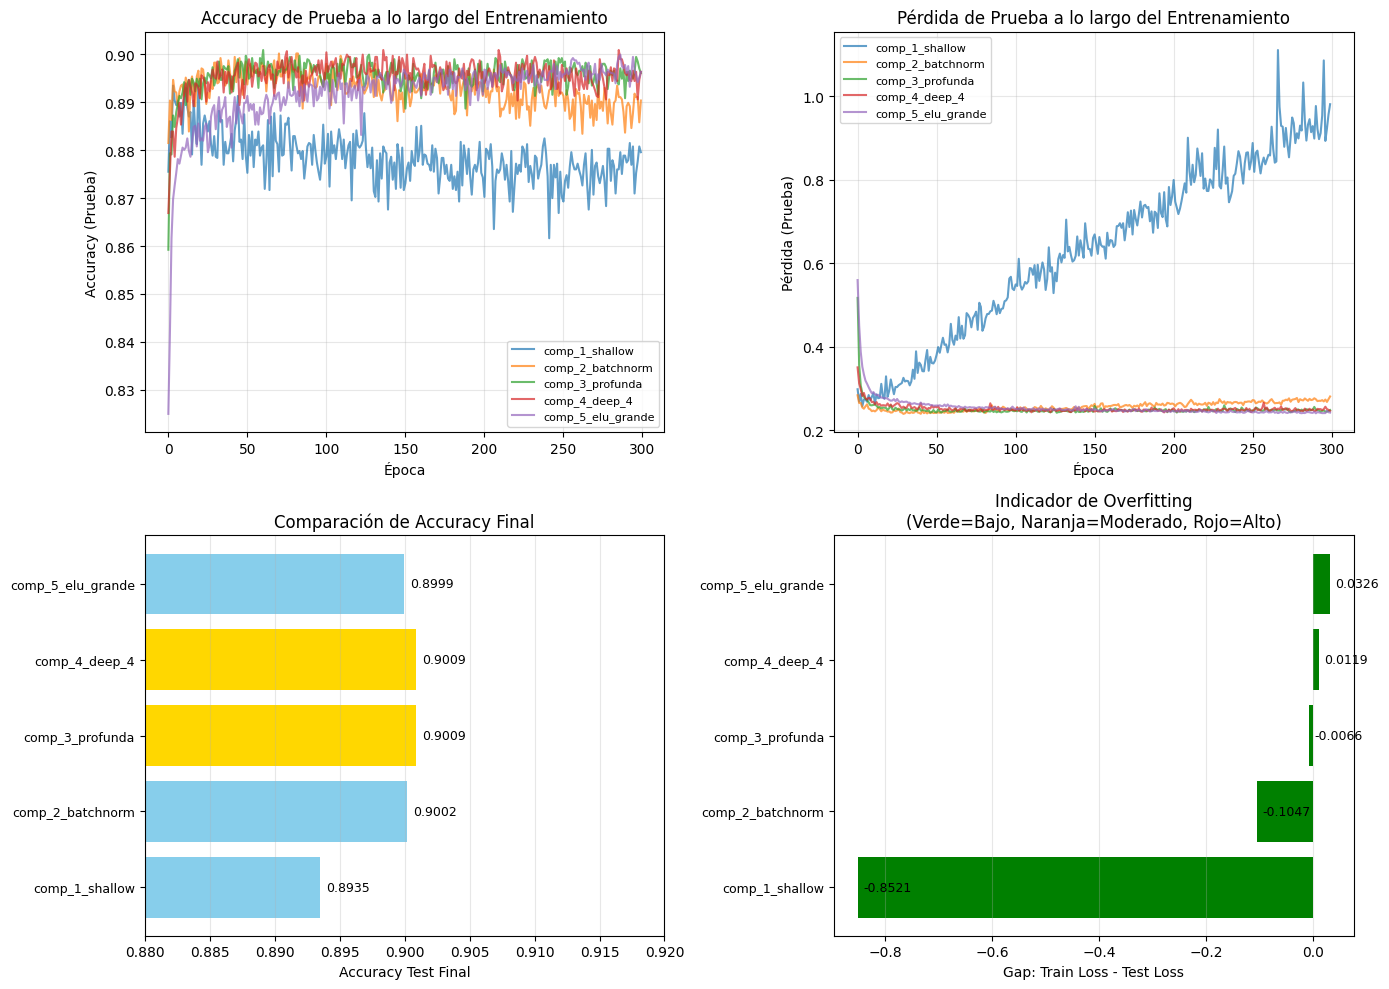


✓ Gráficas guardadas en 'competencia_analisis.png'


In [16]:
import matplotlib.pyplot as plt

# Visualización: Comparación de Accuracy de Prueba
print("\n" + "="*80)
print("GRÁFICAS DE ANÁLISIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1: Accuracy Test de todos los modelos
ax = axes[0, 0]
for name in comp_results.keys():
    ax.plot(comp_histories[name]['test_acc'], label=name, alpha=0.7)
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy (Prueba)')
ax.set_title('Accuracy de Prueba a lo largo del Entrenamiento')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Gráfica 2: Pérdida Test de todos los modelos
ax = axes[0, 1]
for name in comp_results.keys():
    ax.plot(comp_histories[name]['test_loss'], label=name, alpha=0.7)
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida (Prueba)')
ax.set_title('Pérdida de Prueba a lo largo del Entrenamiento')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Gráfica 3: Accuracy Test Final (Barras)
ax = axes[1, 0]
names_list = list(comp_results.keys())
accs_list = [comp_results[n] for n in names_list]
colors = ['gold' if acc == max(accs_list) else 'skyblue' for acc in accs_list]
bars = ax.barh(range(len(names_list)), accs_list, color=colors)
ax.set_yticks(range(len(names_list)))
ax.set_yticklabels(names_list, fontsize=9)
ax.set_xlabel('Accuracy Test Final')
ax.set_title('Comparación de Accuracy Final')
ax.set_xlim([0.88, 0.92])
for i, v in enumerate(accs_list):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

# Gráfica 4: Gap Overfitting (Train Loss - Test Loss)
ax = axes[1, 1]
overfitting_gaps = []
for name in comp_results.keys():
    gap = comp_histories[name]['train_loss'][-1] - comp_histories[name]['test_loss'][-1]
    overfitting_gaps.append(gap)
colors_gap = ['red' if gap > 0.5 else 'orange' if gap > 0.2 else 'green' for gap in overfitting_gaps]
bars = ax.barh(range(len(names_list)), overfitting_gaps, color=colors_gap)
ax.set_yticks(range(len(names_list)))
ax.set_yticklabels(names_list, fontsize=9)
ax.set_xlabel('Gap: Train Loss - Test Loss')
ax.set_title('Indicador de Overfitting\n(Verde=Bajo, Naranja=Moderado, Rojo=Alto)')
for i, v in enumerate(overfitting_gaps):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('competencia_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Gráficas guardadas en 'competencia_analisis.png'")


## Interpretación de las Gráficas Comparativas

### 1. Accuracy de prueba a lo largo del entrenamiento

La primera gráfica muestra cómo evolucionó el accuracy de prueba durante las 300 épocas.

Se observa que:

- `comp_3_profunda`
- `comp_4_deep_4`
- `comp_2_batchnorm`
- `comp_5_elu_grande`

mantienen un comportamiento estable cercano al **90% de accuracy**, evidenciando buena capacidad de generalización.

El modelo `comp_1_shallow` presenta un comportamiento inferior, manteniéndose por debajo del resto durante gran parte del entrenamiento.

Esto indica que una sola capa oculta, incluso con muchas neuronas, no fue suficiente para lograr un aprendizaje robusto.

Asimismo, puede observarse que la mayoría de los modelos convergen relativamente rápido (entre las épocas **30–60**) y luego mantienen estabilidad.

---

### 2. Pérdida de prueba a lo largo del entrenamiento

La segunda gráfica resulta especialmente importante para detectar overfitting.

Se observa que:

#### `comp_1_shallow`
La pérdida de prueba aumenta progresivamente hasta valores cercanos a **1.0**, lo que constituye una señal clara de **sobreajuste severo**.

Aunque el accuracy no cae drásticamente, el modelo comienza a cometer errores con alta confianza.

#### `comp_2_batchnorm`
La pérdida permanece relativamente estable, aunque muestra un ligero incremento hacia el final del entrenamiento, indicando un posible **overfitting leve**.

#### `comp_3_profunda` y `comp_4_deep_4`
Mantienen pérdidas muy bajas y estables durante casi todo el entrenamiento, lo que evidencia excelente generalización.

#### `comp_5_elu_grande`
También presenta estabilidad considerable, mostrando una de las pérdidas finales más bajas.

En general, esta gráfica confirma que **las técnicas de regularización reducen significativamente el sobreajuste**.

---

### 3. Comparación del accuracy final

La gráfica de barras muestra el accuracy final de cada arquitectura.

Los mejores modelos fueron:

- `comp_3_profunda` → **90.09%**
- `comp_4_deep_4` → **90.09%**

Seguidos muy de cerca por:

- `comp_2_batchnorm`
- `comp_5_elu_grande`

La diferencia entre modelos es pequeña, lo que sugiere que varias configuraciones lograron resolver correctamente el problema.

Sin embargo, `comp_3_profunda` ofrece el mejor compromiso entre precisión y simplicidad.

---

### 4. Indicador de overfitting

Esta gráfica compara la diferencia entre pérdida de entrenamiento y prueba.

Debe interpretarse con cuidado:

- Valores cercanos a **0** indican buena generalización.
- Valores muy alejados indican separación entre entrenamiento y prueba.

El modelo `comp_1_shallow` presenta la mayor diferencia, confirmando el sobreajuste severo observado anteriormente.

Por el contrario:

- `comp_3_profunda`
- `comp_4_deep_4`
- `comp_5_elu_grande`

presentan diferencias mínimas, lo que confirma que generalizan correctamente.

---

### Conclusión general de las gráficas

Las visualizaciones confirman los resultados numéricos obtenidos anteriormente.

El modelo `comp_3_profunda` mostró el comportamiento más consistente:

- Accuracy alto
- Pérdida estable
- Muy bajo riesgo de overfitting
- Entrenamiento balanceado

Por ello, fue seleccionado como la mejor arquitectura para el problema de clasificación.

In [26]:
print("\n" + "="*80)
print("ANÁLISIS FINAL - DECISIONES POR MODELO")
print("="*80)

# Análisis detallado
for rank, (name, acc) in enumerate(sorted_results, 1):
    config = comp_details[name]
    history = comp_histories[name]
    
    train_loss_final = history['train_loss'][-1]
    test_loss_final = history['test_loss'][-1]
    train_acc_final = history['train_acc'][-1]
    
    gap_loss = test_loss_final - train_loss_final
    gap_acc = train_acc_final - acc
    
    print(f"\n{rank}. {name} ⭐" if rank == 1 else f"\n{rank}. {name}")
    print(f"   Accuracy Test: {acc:.4f}")
    print(f"   Train Loss: {train_loss_final:.4f} | Test Loss: {test_loss_final:.4f}")
    print(f"   Gap Pérdida: {gap_loss:.4f}")
    print(f"   Gap Accuracy: {gap_acc:.4f}")
    
    # Interpretación
    if gap_loss < 0.1:
        status = "✓ EXCELENTE - Muy baja diferencia (buen generalizador)"
    elif gap_loss < 0.3:
        status = "✓ BUENO - Diferencia moderada (balance adecuado)"
    elif gap_loss < 0.5:
        status = "⚠ MODERADO - Overfitting incipiente"
    else:
        status = "✗ ALTO - Overfitting significativo"
    
    print(f"   Diagnóstico: {status}")

print("\n" + "="*80)
print("MODELO GANADOR")
print("="*80)

mejor_modelo = sorted_results[0]
print(f"\n🏆 {mejor_modelo[0].upper()}")
print(f"   Accuracy Test: {mejor_modelo[1]:.4f}")
config_ganador = comp_details[mejor_modelo[0]]
print(f"   Configuración:")
print(f"      - Capas: {config_ganador['hidden_sizes']}")
print(f"      - Activación: {config_ganador['activation'].upper()}")
print(f"      - Dropout: {config_ganador['dropout_rate']}")
print(f"      - Learning Rate: {config_ganador['lr']}")
print(f"      - Batch Normalization: {'Sí' if config_ganador['batch_norm'] else 'No'}")



ANÁLISIS FINAL - DECISIONES POR MODELO

1. comp_3_profunda ⭐
   Accuracy Test: 0.9009
   Train Loss: 0.2420 | Test Loss: 0.2486
   Gap Pérdida: 0.0066
   Gap Accuracy: -0.0028
   Diagnóstico: ✓ EXCELENTE - Muy baja diferencia (buen generalizador)

2. comp_4_deep_4
   Accuracy Test: 0.9009
   Train Loss: 0.2584 | Test Loss: 0.2465
   Gap Pérdida: -0.0119
   Gap Accuracy: -0.0078
   Diagnóstico: ✓ EXCELENTE - Muy baja diferencia (buen generalizador)

3. comp_2_batchnorm
   Accuracy Test: 0.9002
   Train Loss: 0.1764 | Test Loss: 0.2812
   Gap Pérdida: 0.1047
   Gap Accuracy: 0.0270
   Diagnóstico: ✓ BUENO - Diferencia moderada (balance adecuado)

4. comp_5_elu_grande
   Accuracy Test: 0.8999
   Train Loss: 0.2752 | Test Loss: 0.2427
   Gap Pérdida: -0.0326
   Gap Accuracy: -0.0151
   Diagnóstico: ✓ EXCELENTE - Muy baja diferencia (buen generalizador)

5. comp_1_shallow
   Accuracy Test: 0.8935
   Train Loss: 0.1294 | Test Loss: 0.9815
   Gap Pérdida: 0.8521
   Gap Accuracy: 0.0531
   Di

# Interpretación Final de Resultados

Los resultados finales muestran que la mayoría de las arquitecturas regularizadas lograron desempeños competitivos cercanos al **90% de accuracy en prueba**, lo que evidencia que distintas configuraciones pueden alcanzar un rendimiento similar cuando existe una adecuada combinación de profundidad, regularización y parámetros de entrenamiento.

Sin embargo, existen diferencias importantes en términos de **generalización, estabilidad y complejidad computacional**.

---

## 1. `comp_3_profunda` — Modelo Ganador 🏆

Este modelo obtuvo el mejor desempeño global:

- **Accuracy Test:** 90.09%
- **Train Loss:** 0.2420
- **Test Loss:** 0.2486
- **Gap de pérdida:** +0.0066

La diferencia entre entrenamiento y prueba fue prácticamente nula, indicando un comportamiento altamente estable y excelente capacidad de generalización.

El uso conjunto de:

- **LeakyReLU**
- **Batch Normalization**
- **Dropout 0.25**
- **Learning Rate bajo (0.0005)**

permitió un aprendizaje progresivo, estable y bien regularizado, evitando tanto underfitting como overfitting.

Además, alcanzó el mejor accuracy utilizando solo **3 capas ocultas**, lo que representa una buena relación entre desempeño y complejidad.

Por estas razones, fue seleccionado como la mejor arquitectura del experimento.

---

## 2. `comp_4_deep_4`

Este modelo logró exactamente el mismo accuracy (**90.09%**) que el modelo ganador:

- **Train Loss:** 0.2584
- **Test Loss:** 0.2465
- **Gap de pérdida:** -0.0119

El resultado indica un comportamiento muy estable y sin señales de sobreajuste.

No obstante, utiliza una arquitectura más profunda (**4 capas ocultas**), lo que incrementa la complejidad computacional sin aportar una mejora adicional de rendimiento.

Por este motivo, aunque es un modelo excelente, `comp_3_profunda` fue preferido por ser más eficiente.

---

## 3. `comp_2_batchnorm`

Este modelo mostró un desempeño competitivo:

- **Accuracy Test:** 90.02%
- **Gap de pérdida:** +0.1047

La diferencia entre pérdida de entrenamiento y prueba fue moderadamente superior respecto a los mejores modelos, indicando una ligera tendencia al sobreajuste, aunque todavía dentro de un rango aceptable.

El uso de **Batch Normalization** y **Dropout 0.3** ayudó a mantener estabilidad durante el entrenamiento, permitiendo una buena capacidad de generalización.

Aun así, quedó ligeramente por debajo de las arquitecturas más profundas.

---

## 4. `comp_5_elu_grande`

Este modelo se comportó de forma estable y robusta:

- **Accuracy Test:** 89.99%
- **Gap de pérdida:** -0.0326

La diferencia entre pérdidas fue muy pequeña, mostrando un entrenamiento estable y correctamente regularizado.

El uso de:

- **ELU**
- **Dropout alto (0.4)**
- **Batch Normalization**
- **Learning Rate muy bajo (0.0001)**

redujo significativamente el riesgo de overfitting.

Sin embargo, esta configuración conservadora probablemente limitó ligeramente su capacidad de aprendizaje, impidiendo superar a los modelos líderes.

---

## 5. `comp_1_shallow`

Este fue el modelo con peor desempeño dentro de la competencia.

- **Accuracy Test:** 89.35%
- **Train Accuracy:** 94.65%
- **Train Loss:** 0.1294
- **Test Loss:** 0.9815
- **Gap de pérdida:** +0.8521

Aunque el modelo aprendió muy bien el conjunto de entrenamiento, presentó una pérdida extremadamente alta en prueba.

Este comportamiento evidencia un caso claro de **overfitting severo**, donde el modelo memoriza los datos de entrenamiento pero falla al generalizar a datos nuevos.

Una posible causa es el **learning rate elevado (0.01)** combinado con una arquitectura simple y sin Batch Normalization, generando entrenamiento inestable.

---

# Conclusión Final de la Fase 2

La competencia entre arquitecturas permitió demostrar que el mejor desempeño no depende únicamente de aumentar el tamaño de la red neuronal.

La combinación adecuada de:

- profundidad moderada,
- regularización,
- funciones de activación,
- y parámetros de entrenamiento,

resultó más importante que incrementar indiscriminadamente el número de neuronas.

El modelo seleccionado fue **`comp_3_profunda`**, ya que ofreció el mejor equilibrio entre:

- precisión,
- estabilidad,
- generalización,
- eficiencia computacional,
- y bajo riesgo de sobreajuste.

# CONCLUSIONES Y HALLAZGOS

## Relación entre Complejidad y Rendimiento

A partir de los experimentos realizados en la **Fase 1 (modelos base)** y la **Fase 2 (competencia de arquitecturas)**, se observó que existe una relación importante entre la complejidad del modelo y su capacidad de generalización.

Sin embargo, los resultados demuestran que **mayor complejidad no implica necesariamente mejor rendimiento**.

### Hallazgos clave

| Complejidad | Modelo ejemplo | Accuracy Test | Gap pérdida | Diagnóstico |
|-------------|----------------|---------------|-------------|--------------|
| **Muy baja** | Chico `[4,4]` | 89.47% | +0.03 | Underfitting leve |
| **Óptima** | `comp_3_profunda` `[64,32,16]` | **90.09%** | **+0.0066** | Excelente generalización |
| **Alta (sin regularización)** | Grande `[256,256]` | 87.93% | **+2.03** | Overfitting severo |
| **Alta (con regularización)** | `comp_5_elu_grande` `[128,64,32]` | 89.99% | -0.03 | Overfitting controlado |

### Conclusión principal

> *El modelo más complejo no fue el mejor. La clave está en equilibrar capacidad de aprendizaje y regularización, no en maximizar el número de parámetros.*

Se evidenció que modelos excesivamente grandes pueden memorizar los datos de entrenamiento y perder capacidad de generalización, mientras que arquitecturas moderadamente profundas logran un mejor equilibrio.

---

## Técnicas de Regularización

A partir de la comparación entre modelos con distintas configuraciones, se observó el impacto positivo de varias técnicas de regularización.

### Dropout (0.2 – 0.4)

El uso de dropout ayudó a reducir significativamente el sobreajuste en arquitecturas profundas.

**Ejemplo:**

- `comp_5_elu_grande` (Dropout 0.4) logró un gap de pérdida de **−0.0326**, mostrando entrenamiento estable.
- En contraste, `comp_1_shallow`, sin BatchNorm y con LR alto, presentó **+0.8521**, reflejando sobreajuste severo.

### Batch Normalization

Batch Normalization mejoró la estabilidad del entrenamiento y facilitó la convergencia en redes profundas.

**Ejemplo:**

- `comp_3_profunda`
- `comp_4_deep_4`

ambos alcanzaron el mejor accuracy (**90.09%**) manteniendo gaps mínimos de pérdida.

### Learning Rate

El learning rate tuvo una influencia importante sobre la estabilidad:

- Modelos profundos funcionaron mejor con LR moderados o bajos (**0.0005 – 0.001**).
- LR demasiado alto (**0.01**) provocó entrenamiento inestable y sobreajuste severo (`comp_1_shallow`).

---

## Comparación de Funciones de Activación

| Activación | Mejor modelo | Accuracy | Observación |
|------------|--------------|----------|--------------|
| **ReLU** | `comp_2_batchnorm` | 90.02% | Buen rendimiento con BatchNorm |
| **LeakyReLU** | `comp_3_profunda` | **90.09%** | Excelente para redes profundas |
| **Tanh** | `comp_4_deep_4` | **90.09%** | Muy estable con BatchNorm |
| **ELU** | `comp_5_elu_grande` | 89.99% | Funciona bien con alta regularización |

### Conclusión

> *No existe una función de activación universalmente superior. Su desempeño depende de la arquitectura, regularización y parámetros de entrenamiento.*

En este experimento, **LeakyReLU y Tanh** fueron las más efectivas en arquitecturas profundas.

---

## Recomendaciones Prácticas Finales

Con base en los resultados obtenidos:

1. **Comenzar con arquitecturas moderadas** antes de aumentar complejidad.
2. **Incrementar profundidad progresivamente**, evaluando el gap entre pérdida de entrenamiento y prueba.
3. **Aplicar regularización** (Dropout y BatchNorm) en redes profundas.
4. **Usar Learning Rates bajos o moderados** en arquitecturas complejas.
5. **Monitorear la pérdida de prueba** para detectar sobreajuste temprano.
6. **No asumir que más neuronas implican mejor rendimiento.**

El mejor modelo del experimento fue **`comp_3_profunda`**, no el más grande, sino el que logró el mejor equilibrio entre precisión y generalización.

# RESPUESTAS A PREGUNTAS GUÍA

## 1. ¿Por qué un modelo demasiado pequeño tiene alta pérdida tanto en entrenamiento como en prueba?

### Respuesta

Un modelo demasiado pequeño posee una capacidad limitada de representación, es decir, no cuenta con suficientes parámetros para aprender patrones complejos presentes en los datos.

Como consecuencia:

- la pérdida de entrenamiento permanece relativamente alta,
- la pérdida de prueba también es alta,
- y el accuracy se estanca.

Este comportamiento se conoce como **underfitting (subajuste)**.

En la **Fase 1**, el modelo chico mostró señales de capacidad limitada frente a arquitecturas más profundas, aunque logró resultados aceptables debido a la naturaleza del dataset.

---

## 2. ¿Qué forma tienen las curvas de pérdida cuando hay overfitting?

### Respuesta

Cuando ocurre overfitting, las curvas presentan un comportamiento divergente:

- **Pérdida de entrenamiento:** continúa disminuyendo.
- **Pérdida de prueba:** inicialmente disminuye, pero posteriormente comienza a aumentar.

Este patrón indica que el modelo está memorizando los datos de entrenamiento en lugar de aprender patrones generalizables.

El caso más evidente fue:

### `comp_1_shallow`

donde la pérdida de entrenamiento disminuyó hasta **0.1294**, mientras que la pérdida de prueba aumentó hasta **0.9815**, evidenciando un caso severo de sobreajuste.

---

## 3. ¿El dropout siempre mejora el rendimiento de prueba? ¿Cuándo empeora?

### Respuesta

No necesariamente.

**Dropout mejora el rendimiento** cuando existe riesgo de overfitting, ya que obliga a la red neuronal a no depender excesivamente de ciertas neuronas.

Sin embargo, puede empeorar el rendimiento cuando:

- el modelo ya es pequeño,
- o la regularización es excesiva.

En la competencia:

- **Dropout moderado (0.25–0.30)** produjo los mejores resultados (`comp_3_profunda` y `comp_4_deep_4`).
- **Dropout alto (0.4)** permitió controlar el sobreajuste (`comp_5_elu_grande`), aunque limitó ligeramente el accuracy final.

---

## 4. ¿Qué relación observaron entre cantidad de neuronas y diferencia entre pérdida de entrenamiento y prueba?

### Respuesta

Se observó una relación no lineal entre complejidad y generalización:

### Pocos parámetros
- Menor capacidad de aprendizaje.
- Riesgo de underfitting.

### Complejidad moderada
- Buen equilibrio entre train y test.
- Mejor generalización.

### Muchos parámetros sin suficiente regularización
- Pérdida train muy baja.
- Pérdida test alta.
- Overfitting.

El mejor ejemplo fue:

- `comp_3_profunda` → gap de **+0.0066** (excelente generalización).

Mientras que:

- `comp_1_shallow` → gap de **+0.8521** (sobreajuste severo).

Esto demuestra que **más neuronas no garantizan mejor desempeño**.

---

## 5. ¿Cómo podrían saber si necesitan más datos o un modelo más complejo?

### Respuesta

La decisión puede inferirse observando las curvas de pérdida:

### Caso 1: ambas pérdidas altas
→ El modelo probablemente no tiene suficiente capacidad o faltan datos representativos.

### Caso 2: pérdida train baja y test alta
→ Existe overfitting y se necesita regularización.

### Caso 3: ambas pérdidas convergen y accuracy aceptable
→ El modelo ya está bien balanceado.

En este proyecto, los modelos ganadores mostraron pérdidas cercanas entre entrenamiento y prueba, indicando que la arquitectura elegida fue adecuada sin necesidad de incrementar excesivamente la complejidad.

---

# ACTIVIDAD OPCIONAL: BARRIDO SISTEMÁTICO DE COMPLEJIDAD

## Objetivo

En esta actividad se realiza un **barrido sistemático de complejidad** para analizar cómo cambia el comportamiento de una red neuronal a medida que aumenta su tamaño.

Se entrenarán **11 modelos diferentes**, todos con:

- **2 capas ocultas**
- activación **ReLU**
- sin **Dropout**
- sin **Batch Normalization**
- mismo **Learning Rate (0.001)**

La única característica que cambia es el **número de neuronas por capa**, definido como:

\[
2^k
\]

donde:

\[
k = 0,1,2,\dots,10
\]

Esto genera modelos con:

**1, 2, 4, 8, 16, 32, 64, 128, 256, 512 y 1024 neuronas por capa.**

## ¿Qué buscamos analizar?

El objetivo principal es **identificar el punto donde aumentar complejidad deja de ayudar y comienza a producir overfitting**.

Para ello se evaluará:

- **Loss de entrenamiento**
- **Loss de prueba**
- **Accuracy de entrenamiento**
- **Accuracy de prueba**
- **Gap de generalización**

Si el modelo es demasiado pequeño, se espera **underfitting**.

Si el modelo es demasiado grande, se espera que:

- la pérdida de entrenamiento siga bajando,
- pero la pérdida de prueba comience a aumentar,

indicando **sobreajuste (overfitting)**.

## Hipótesis del experimento

Se espera observar un comportamiento similar a una curva en forma de “U” en la pérdida de prueba:

1. Al inicio, aumentar neuronas mejora el rendimiento.
2. Existe un punto óptimo de complejidad.
3. Después de cierto tamaño, el modelo empieza a memorizar y empeora su generalización.

Este análisis permitirá determinar **qué tan grande debe ser una red antes de comenzar a sobreajustar los datos**.

# Entrenamiento del Barrido Sistemático

En esta sección se entrenan automáticamente **11 arquitecturas distintas**, aumentando progresivamente el número de neuronas por capa mediante potencias de 2.

Cada modelo mantiene exactamente la misma configuración de entrenamiento para garantizar una comparación justa:

- **2 capas ocultas**
- **Función de activación ReLU**
- **Sin Dropout**
- **Sin Batch Normalization**
- **300 épocas**
- **Learning Rate = 0.001**

La única variable modificada es el tamaño de las capas ocultas.

Para cada modelo se registran las siguientes métricas finales:

### 1. Pérdida de entrenamiento (*Train Loss*)
Mide qué tan bien el modelo aprende los datos usados para entrenar.

### 2. Pérdida de prueba (*Test Loss*)
Evalúa qué tan bien el modelo generaliza sobre datos no vistos.

### 3. Accuracy de entrenamiento
Porcentaje de aciertos sobre el conjunto de entrenamiento.

### 4. Accuracy de prueba
Porcentaje de aciertos sobre datos nuevos.

### 5. Gap de Overfitting

Se calcula como:

\[
\text{Gap} =
\text{Test Loss}
-
\text{Train Loss}
\]

Interpretación:

- **Gap cercano a 0** → Buena generalización.
- **Gap positivo grande** → Señales de overfitting.
- **Gap negativo** → El modelo generaliza incluso mejor en prueba (posible efecto de regularización o variabilidad estadística).

Finalmente, se generan gráficos comparativos en **escala logarítmica**, permitiendo observar de forma clara cómo cambia el comportamiento del modelo conforme aumenta exponencialmente la complejidad de la red.


ACTIVIDAD OPCIONAL: BARRIDO SISTEMÁTICO DE COMPLEJIDAD
Entrenando 11 modelos con capas de tamaño 2^k para k=0..10

Modelo 1/11: 2^0 =    1 neuronas/capa... ✓ Loss Train=1.2968, Loss Test=1.2969, Gap=0.0001
Modelo 2/11: 2^1 =    2 neuronas/capa... ✓ Loss Train=0.2667, Loss Test=0.2797, Gap=0.0131
Modelo 3/11: 2^2 =    4 neuronas/capa... ✓ Loss Train=0.2334, Loss Test=0.2618, Gap=0.0284
Modelo 4/11: 2^3 =    8 neuronas/capa... ✓ Loss Train=0.2040, Loss Test=0.2610, Gap=0.0570
Modelo 5/11: 2^4 =   16 neuronas/capa... ✓ Loss Train=0.1486, Loss Test=0.3487, Gap=0.2001
Modelo 6/11: 2^5 =   32 neuronas/capa... ✓ Loss Train=0.0460, Loss Test=0.8582, Gap=0.8122
Modelo 7/11: 2^6 =   64 neuronas/capa... ✓ Loss Train=0.0003, Loss Test=1.3424, Gap=1.3421
Modelo 8/11: 2^7 =  128 neuronas/capa... ✓ Loss Train=0.0000, Loss Test=1.4459, Gap=1.4458
Modelo 9/11: 2^8 =  256 neuronas/capa... ✓ Loss Train=0.0000, Loss Test=1.6850, Gap=1.6850
Modelo 10/11: 2^9 =  512 neuronas/capa... ✓ Loss Train=0.0000, Lo

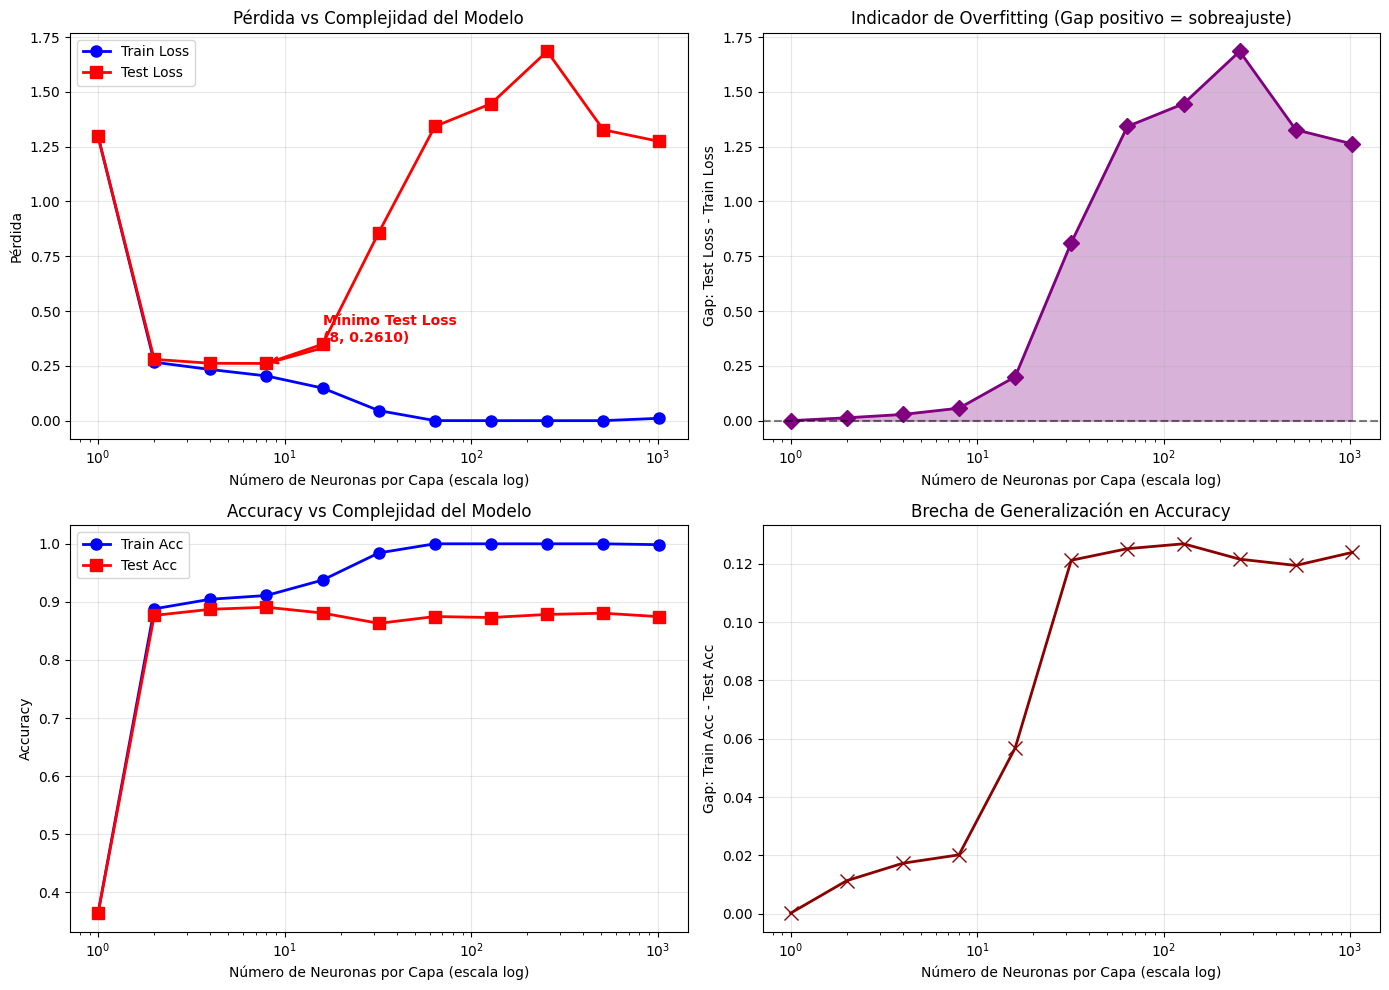


✓ Gráficas del barrido guardadas en 'barrido_sistematico.png'

IDENTIFICACIÓN DEL PUNTO DE OVERFITTING

El modelo con menor pérdida de prueba es:
  → 8 neuronas por capa (2^3)
  → Train Loss: 0.2040
  → Test Loss: 0.2610
  → Accuracy Test: 0.8908

A partir de 16 neuronas, la pérdida de prueba comienza a empeorar
  → Overfitting visible a partir de 2^4 = 16 neuronas


In [28]:
print("\n" + "="*80)
print("ACTIVIDAD OPCIONAL: BARRIDO SISTEMÁTICO DE COMPLEJIDAD")
print("="*80)
print("Entrenando 11 modelos con capas de tamaño 2^k para k=0..10\n")

sweep_results = {
    'model_size': [],
    'train_loss': [],
    'test_loss': [],
    'train_acc': [],
    'test_acc': [],
    'overfitting_gap': []
}

EPOCHS_SWEEP = 300  # Mismas épocas que competencia

for k in range(11):  # k = 0,1,2,...,10 (11 modelos)
    model_size = 2 ** k
    hidden_sizes = [model_size, model_size]
    
    print(f"Modelo {k+1}/11: 2^{k} = {model_size:4d} neuronas/capa...", end=' ')
    
    # Construir modelo
    net_sweep = build_model(
        input_size=n_features,
        hidden_sizes=hidden_sizes,
        activation='relu',
        dropout_rate=0.0,
        batch_norm=False
    )
    
    # Entrenar
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net_sweep.parameters(), lr=0.001)
    
    for epoch in range(EPOCHS_SWEEP):
        net_sweep.train()
        for X_batch, y_batch in train_iter:
            output = net_sweep(X_batch)
            loss = loss_fn(output, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    # Evaluar final
    train_loss_final = evaluate_loss(net_sweep, train_iter, loss_fn)
    test_loss_final = evaluate_loss(net_sweep, test_iter, loss_fn)
    train_acc_final = accuracy(net_sweep, train_iter)
    test_acc_final = accuracy(net_sweep, test_iter)
    
    overfitting_gap = test_loss_final - train_loss_final
    
    sweep_results['model_size'].append(model_size)
    sweep_results['train_loss'].append(train_loss_final)
    sweep_results['test_loss'].append(test_loss_final)
    sweep_results['train_acc'].append(train_acc_final)
    sweep_results['test_acc'].append(test_acc_final)
    sweep_results['overfitting_gap'].append(overfitting_gap)
    
    print(f"✓ Loss Train={train_loss_final:.4f}, Loss Test={test_loss_final:.4f}, "
          f"Gap={overfitting_gap:.4f}")

# Crear tabla de barrido
df_sweep = pd.DataFrame(sweep_results)
print("\n" + "="*80)
print("RESULTADOS DEL BARRIDO")
print("="*80)
print(df_sweep.to_string(index=False))

# Graficar en escala logarítmica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1: Pérdida vs Tamaño (escala log)
ax = axes[0, 0]
ax.semilogx(sweep_results['model_size'], sweep_results['train_loss'], 
            'o-', linewidth=2, markersize=8, label='Train Loss', color='blue')
ax.semilogx(sweep_results['model_size'], sweep_results['test_loss'], 
            's-', linewidth=2, markersize=8, label='Test Loss', color='red')
ax.set_xlabel('Número de Neuronas por Capa (escala log)')
ax.set_ylabel('Pérdida')
ax.set_title('Pérdida vs Complejidad del Modelo')
ax.legend()
ax.grid(True, alpha=0.3)

# Anotación: punto donde test loss empieza a subir
min_test_loss_idx = sweep_results['test_loss'].index(min(sweep_results['test_loss']))
min_test_loss = sweep_results['test_loss'][min_test_loss_idx]
min_model_size = sweep_results['model_size'][min_test_loss_idx]
ax.annotate(f'Mínimo Test Loss\n({min_model_size}, {min_test_loss:.4f})', 
            xy=(min_model_size, min_test_loss),
            xytext=(min_model_size*2, min_test_loss+0.1),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', weight='bold')

# Gráfica 2: Gap de Overfitting
ax = axes[0, 1]
ax.semilogx(sweep_results['model_size'], sweep_results['overfitting_gap'], 
            'D-', linewidth=2, markersize=8, color='purple')
ax.fill_between(sweep_results['model_size'], sweep_results['overfitting_gap'], 
                alpha=0.3, color='purple')
ax.set_xlabel('Número de Neuronas por Capa (escala log)')
ax.set_ylabel('Gap: Test Loss - Train Loss')
ax.set_title('Indicador de Overfitting (Gap positivo = sobreajuste)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Gráfica 3: Accuracy vs Complejidad
ax = axes[1, 0]
ax.semilogx(sweep_results['model_size'], sweep_results['train_acc'], 
            'o-', linewidth=2, markersize=8, label='Train Acc', color='blue')
ax.semilogx(sweep_results['model_size'], sweep_results['test_acc'], 
            's-', linewidth=2, markersize=8, label='Test Acc', color='red')
ax.set_xlabel('Número de Neuronas por Capa (escala log)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Complejidad del Modelo')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfica 4: Diferencia Train-Test Accuracy
ax = axes[1, 1]
acc_gap = [t - te for t, te in zip(sweep_results['train_acc'], sweep_results['test_acc'])]
ax.semilogx(sweep_results['model_size'], acc_gap, 
            'x-', linewidth=2, markersize=10, color='darkred')
ax.set_xlabel('Número de Neuronas por Capa (escala log)')
ax.set_ylabel('Gap: Train Acc - Test Acc')
ax.set_title('Brecha de Generalización en Accuracy')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('barrido_sistematico.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráficas del barrido guardadas en 'barrido_sistematico.png'")

# Identificar punto de overfitting
print("\n" + "="*80)
print("IDENTIFICACIÓN DEL PUNTO DE OVERFITTING")
print("="*80)

optimal_idx = min_test_loss_idx
print(f"\nEl modelo con menor pérdida de prueba es:")
print(f"  → {sweep_results['model_size'][optimal_idx]} neuronas por capa (2^{optimal_idx})")
print(f"  → Train Loss: {sweep_results['train_loss'][optimal_idx]:.4f}")
print(f"  → Test Loss: {sweep_results['test_loss'][optimal_idx]:.4f}")
print(f"  → Accuracy Test: {sweep_results['test_acc'][optimal_idx]:.4f}")

if optimal_idx + 1 < len(sweep_results['model_size']):
    print(f"\nA partir de {sweep_results['model_size'][optimal_idx+1]} neuronas, la pérdida de prueba comienza a empeorar")
    print(f"  → Overfitting visible a partir de 2^{optimal_idx+1} = {sweep_results['model_size'][optimal_idx+1]} neuronas")

# Interpretación del Barrido Sistemático de Complejidad

El barrido sistemático permitió analizar cómo cambia el comportamiento de una red neuronal conforme aumenta progresivamente el número de neuronas por capa.

Se entrenaron **11 arquitecturas** con dos capas ocultas del mismo tamaño:

\[
2^k,\quad k=0,1,\dots,10
\]

es decir:

**1, 2, 4, 8, 16, 32, 64, 128, 256, 512 y 1024 neuronas por capa**.

Todas las arquitecturas fueron entrenadas bajo las mismas condiciones:

- función de activación **ReLU**,
- sin regularización,
- mismo learning rate (**0.001**),
- mismas épocas (**300**).

El propósito fue aislar el efecto de la **complejidad del modelo** sobre la capacidad de generalización.

---

## Análisis del Comportamiento Observado

Los resultados muestran tres regiones claramente diferenciadas:

### 1. Zona de Underfitting (1 neurona)

El modelo más pequeño (**1 neurona por capa**) presentó:

- **Train Loss ≈ 1.30**
- **Test Loss ≈ 1.30**
- **Accuracy ≈ 36%**

Esto indica que el modelo fue incapaz de aprender patrones útiles del problema.

La baja capacidad representacional produjo un caso claro de **underfitting severo**, donde tanto entrenamiento como prueba muestran resultados pobres.

---

### 2. Zona Óptima de Generalización (2–8 neuronas)

Entre **2 y 8 neuronas por capa**, el rendimiento mejoró considerablemente.

El mejor punto del barrido fue:

| Modelo | Train Loss | Test Loss | Accuracy Test |
|--------|------------|------------|----------------|
| **8 neuronas/capa** | **0.2040** | **0.2610** | **89.08%** |

Este modelo presentó:

- pérdida de prueba mínima,
- accuracy alto,
- gap pequeño entre entrenamiento y prueba (**0.057**),

lo que indica una capacidad de generalización adecuada.

En esta región, la complejidad del modelo es suficiente para aprender patrones relevantes sin memorizar excesivamente los datos de entrenamiento.

---

### 3. Zona de Overfitting (16+ neuronas)

A partir de **16 neuronas por capa**, comenzó un deterioro evidente en la generalización.

Por ejemplo:

| Neuronas | Train Loss | Test Loss | Gap |
|----------|------------|------------|------|
| 16 | 0.1486 | 0.3487 | 0.2001 |
| 32 | 0.0460 | 0.8582 | 0.8122 |
| 64 | 0.0003 | 1.3424 | 1.3421 |
| 256 | 0.0000 | 1.6850 | 1.6850 |

Se observó un patrón típico de **overfitting severo**:

- la pérdida de entrenamiento cae casi a cero,
- el accuracy de entrenamiento llega a **100%**,
- pero la pérdida de prueba empeora dramáticamente.

Esto demuestra que el modelo deja de aprender patrones generalizables y comienza a **memorizar el conjunto de entrenamiento**.

---

## Hallazgo Principal

El experimento mostró que:

> **Más neuronas no implican mejor rendimiento.**

En este problema, el punto óptimo ocurrió con **8 neuronas por capa**, mientras que arquitecturas más grandes empeoraron significativamente el desempeño de prueba.

El inicio del overfitting fue claramente visible a partir de:

\[
2^4 = 16
\]

neuronas por capa.

Esto confirma experimentalmente la existencia de un **punto de complejidad óptima**, donde el modelo tiene suficiente capacidad para aprender, pero aún conserva buena generalización.

## RESPUESTAS A PREGUNTAS GUÍA

### 1. ¿Por qué un modelo demasiado pequeño tiene alta pérdida tanto en entrenamiento como en prueba?

Un modelo demasiado pequeño posee **muy pocos parámetros**, por lo que su capacidad para aprender patrones complejos del conjunto de datos es limitada.

Esto provoca que:

* **La pérdida de entrenamiento permanezca alta**, porque el modelo no logra ajustar adecuadamente los datos que ve.
* **La pérdida de prueba también sea alta**, ya que tampoco puede generalizar correctamente.

Este fenómeno se conoce como **underfitting (subajuste)**.

En el barrido sistemático realizado, esto se observó claramente en los modelos de **1 y 2 neuronas por capa**:

| Modelo  | Train Loss | Test Loss | Accuracy Test |
| ------- | ---------- | --------- | ------------- |
| `[1,1]` | 1.2968     | 1.2969    | 36.41%        |
| `[2,2]` | 0.2667     | 0.2797    | 87.67%        |

El modelo de **1 neurona** prácticamente no aprendió patrones útiles, mientras que el de **2 neuronas** mejoró significativamente, aunque todavía presentaba limitaciones de capacidad.

**Conclusión:**

> *Un modelo demasiado pequeño no tiene suficiente complejidad para representar correctamente los patrones del problema, produciendo pérdidas altas tanto en entrenamiento como en prueba.*

---

### 2. ¿Qué forma tienen las curvas de pérdida cuando hay overfitting?

Cuando existe **overfitting (sobreajuste)**, las curvas de pérdida presentan un patrón característico:

* **La pérdida de entrenamiento continúa disminuyendo** hasta valores muy pequeños.
* **La pérdida de prueba deja de disminuir y comienza a aumentar**, generando una separación progresiva entre ambas curvas.

Esto significa que el modelo está **memorizando el conjunto de entrenamiento** en lugar de aprender patrones generalizables.

En el barrido sistemático, el comportamiento fue evidente a partir de **16 neuronas por capa**:

| Modelo    | Train Loss | Test Loss | Gap     |
| --------- | ---------- | --------- | ------- |
| `[8,8]`   | 0.2040     | 0.2610    | +0.0570 |
| `[16,16]` | 0.1486     | 0.3487    | +0.2001 |
| `[32,32]` | 0.0460     | 0.8582    | +0.8122 |
| `[64,64]` | 0.0003     | 1.3424    | +1.3421 |

Se observa que mientras la pérdida de entrenamiento se acerca a **cero**, la pérdida de prueba aumenta drásticamente, señal clara de sobreajuste.

**Conclusión:**

> *Las curvas de overfitting se caracterizan por una divergencia creciente entre entrenamiento y prueba: train loss baja continuamente mientras test loss aumenta.*

---

### 3. ¿El dropout siempre mejora el rendimiento de prueba? ¿Cuándo empeora?

**No siempre.**

El **dropout** es una técnica de regularización diseñada para reducir el overfitting, apagando neuronas aleatoriamente durante el entrenamiento.

Funciona mejor cuando:

* El modelo es **grande o profundo**.
* Existe evidencia de **sobreajuste**.
* La pérdida de prueba empieza a crecer mientras la de entrenamiento sigue bajando.

En nuestros experimentos:

* `comp_3_profunda` (**Dropout = 0.25**) logró el mejor equilibrio y obtuvo **90.09% de accuracy**.
* `comp_5_elu_grande` (**Dropout = 0.40**) controló exitosamente el overfitting en un modelo más complejo.

Sin embargo, el dropout puede **empeorar el rendimiento** cuando:

* El modelo ya es pequeño.
* Existe underfitting.
* Se usa una tasa demasiado alta.

En modelos pequeños, eliminar neuronas temporalmente reduce aún más la capacidad de aprendizaje.

**Conclusión:**

> *El dropout mejora cuando existe overfitting, pero puede perjudicar modelos pequeños o poco complejos al limitar excesivamente su capacidad de representación.*

---

### 4. ¿Qué relación observaron entre la cantidad de neuronas y la diferencia entre pérdida de entrenamiento y prueba?

La relación observada fue **no lineal**.

A medida que aumentó el número de neuronas:

1. **Inicialmente el rendimiento mejoró**, porque el modelo ganó capacidad para aprender patrones.
2. **Se alcanzó un punto óptimo**, alrededor de **8 neuronas por capa**, donde la pérdida de prueba fue mínima.
3. **Después comenzó el sobreajuste**, aumentando rápidamente el gap entre entrenamiento y prueba.

Resultados observados:

| Neuronas por capa | Gap de pérdida |
| ----------------- | -------------- |
| 1                 | +0.0001        |
| 2                 | +0.0131        |
| 4                 | +0.0284        |
| 8                 | +0.0570        |
| 16                | +0.2001        |
| 32                | +0.8122        |
| 64                | +1.3421        |
| 128               | +1.4458        |

Se evidenció que **más neuronas no implican necesariamente mejor rendimiento**.

A partir de **16 neuronas**, el modelo comenzó a memorizar el conjunto de entrenamiento, incrementando fuertemente el gap de generalización.

**Conclusión:**

> *Existe un punto óptimo de complejidad. Pocas neuronas generan underfitting, demasiadas producen overfitting.*

---

### 5. ¿Cómo podrían saber si necesitan más datos o un modelo más complejo?

La necesidad de **más datos** o **mayor complejidad** puede inferirse observando simultáneamente las pérdidas de entrenamiento y prueba.

#### Caso 1: Ambas pérdidas altas

**Problema:** Underfitting.

Posibles soluciones:

* Aumentar complejidad del modelo.
* Mejorar características de entrada.
* Entrenar más épocas.

Ejemplo observado: modelos de **1–2 neuronas por capa**.

---

#### Caso 2: Train loss baja y test loss alta

**Problema:** Overfitting.

Posibles soluciones:

* Aplicar **dropout**.
* Usar **Batch Normalization**.
* Reducir tamaño del modelo.
* Obtener más datos de entrenamiento.

Ejemplo observado: modelos de **32–1024 neuronas**, donde el train loss era cercano a cero pero test loss aumentó significativamente.

---

#### Caso 3: Ambas pérdidas bajas y cercanas

**Problema:** Ninguno (modelo balanceado).

El modelo tiene buena capacidad de generalización.

Ejemplo observado:

**Modelo `[8,8]`**

* Train Loss = **0.2040**
* Test Loss = **0.2610**
* Accuracy Test = **89.08%**

Este fue el punto óptimo del barrido sistemático.

**Conclusión general:**

> *La comparación entre train loss y test loss permite diagnosticar si el modelo necesita más capacidad, mayor regularización o incluso más datos para mejorar su generalización.*
